In [36]:
# NOTE: All quadratic fit parameters are recomputed from the current run.
# Due to randomness in optimization, values such as S* and band endpoints may shift slightly,
# but the non-monotonic sensitivity–robustness relationship remains consistent.

In [1]:
!pip -q install timm

import os, math, time, json, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ---- Reproducibility ----
def seed_all(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(0)

# ---- Device ----
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("device:", device)

# ---- High-quality plot defaults ----
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})

device: mps


In [2]:
DATA_ROOT = Path("./data").resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# CIFAR-10 normalization (standard)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_tf)

batch_size = 128
num_workers = 0  # mac safe; 

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=False)

print(len(train_ds), len(test_ds))

50000 10000


In [3]:
import torch
import torch.nn as nn
import torchvision

def make_tiny_vit_cifar(num_classes=10):
    """
    Small Vision Transformer for 32x32 CIFAR-10.
    """
    model = torchvision.models.vision_transformer.VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=8,
        hidden_dim=256,
        mlp_dim=512,
        num_classes=num_classes,
        dropout=0.1,
        attention_dropout=0.1,
        representation_size=None,
        norm_layer=lambda dim: nn.LayerNorm(dim, eps=1e-6),
    )
    return model

vit = make_tiny_vit_cifar().to(device)
print("Tiny ViT params:", sum(p.numel() for p in vit.parameters() if p.requires_grad))

Tiny ViT params: 3195146


In [4]:
# Clean accuracy

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

@torch.no_grad()
def _unit_noise_like(x):
    v = torch.randn_like(x)
    B = x.shape[0]
    denom = v.flatten(1).norm(dim=1, keepdim=True).view(B, *([1]*(x.ndim-1))) + 1e-12
    return v / denom

def sensitivity_sigma_mean_fd(model, x, eps=1e-3, n_vecs=2):
    """
    Returns scalar sigma_mean proxy on batch x.
    Uses forward passes only (no higher-order derivatives).
    """
    model.eval()
    x = x.detach()
    with torch.no_grad():
        fx = model(x)  # (B,K)
    vals = []
    for _ in range(n_vecs):
        v = _unit_noise_like(x)
        with torch.no_grad():
            fxp = model(x + eps*v)
        Jv = (fxp - fx) / eps  # (B,K)
        # L2 norm across classes
        vals.append(Jv.norm(dim=1))  # (B,)
    vals = torch.stack(vals, dim=0)  # (n_vecs,B)
    # proxy for operator norm: max over random directions, then mean over batch
    per_ex = vals.max(dim=0).values
    return float(per_ex.mean().item())

In [5]:
C10C_CORRUPTIONS = [
    "gaussian_noise","shot_noise","impulse_noise",
    "defocus_blur","glass_blur","motion_blur","zoom_blur",
    "snow","frost","fog","brightness",
    "contrast","elastic_transform","pixelate","jpeg_compression",
]

def load_c10c_corruption(c10c_dir, corruption, severity):
    """
    Returns (images, labels) for a corruption at a given severity.
    severity in {1..5}. Each severity is a slice of 10k images.
    """
    c10c_dir = Path(c10c_dir)
    x = np.load(c10c_dir / f"{corruption}.npy")  # (50000,32,32,3), uint8
    y = np.load(c10c_dir / "labels.npy")         # (50000,)
    assert 1 <= severity <= 5
    start = (severity-1)*10000
    end   = severity*10000
    return x[start:end], y[start:end]

class CIFAR10CDataset(torch.utils.data.Dataset):
    def __init__(self, x_uint8, y, transform):
        self.x = x_uint8
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        img = self.x[i]  # uint8 HWC
        img = torchvision.transforms.functional.to_pil_image(img)
        img = self.transform(img)
        return img, int(self.y[i])

@torch.no_grad()
def eval_c10c(model, c10c_dir, severity=5, corruptions=None, batch_size=256):
    """
    Evaluate mean accuracy over corruptions at a severity.
    Returns mean, std across corruptions.
    """
    if corruptions is None:
        corruptions = C10C_CORRUPTIONS

    accs = []
    model.eval()
    for corr in corruptions:
        x, y = load_c10c_corruption(c10c_dir, corr, severity)
        ds = CIFAR10CDataset(x, y, transform=test_tf)
        loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        a = eval_acc(model, loader)
        accs.append(a)
    return float(np.mean(accs)), float(np.std(accs)), {c:a for c,a in zip(corruptions, accs)}

In [6]:
import requests
import tarfile

C10C_ROOT = Path("./cifar10c").resolve()
C10C_ROOT.mkdir(parents=True, exist_ok=True)

CIFAR10C_URL = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"

def download_cifar10c(root=C10C_ROOT):
    root = Path(root)
    tar_path = root / "CIFAR-10-C.tar"
    extracted_dir = root / "CIFAR-10-C"
    if extracted_dir.exists():
        print("CIFAR-10-C already extracted at:", extracted_dir)
        return extracted_dir

    if not tar_path.exists():
        print("Downloading CIFAR-10-C tar...")
        r = requests.get(CIFAR10C_URL, stream=True)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(tar_path, "wb") as f:
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc="download")
            for chunk in r.iter_content(chunk_size=1<<20):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
            pbar.close()
        print("Downloaded:", tar_path)

    print("Extracting...")
    with tarfile.open(tar_path, "r") as tf:
        tf.extractall(path=root)
    print("Extracted to:", extracted_dir)
    return extracted_dir

c10c_dir = download_cifar10c(C10C_ROOT)

CIFAR-10-C already extracted at: /Users/singh_h/Downloads/27Feb2026_PseudoSpect_ModelStability/COLM/cifar10c/CIFAR-10-C


/Users/singh_h/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [7]:
def train_vit(
    tag,
    lr,
    weight_decay,
    steps=2000,
    log_every=250,
    eps_fd=1e-3,
    n_vecs=2,
    sens_batch_cap=64,
):
    model = make_tiny_vit_cifar().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    logs = {
        "step": [],
        "train_loss": [],
        "test_acc": [],
        "sigma_mean": [],
        "c10c_acc_mean": [],
        "c10c_acc_std": [],
    }

    it = iter(train_loader)
    pbar = tqdm(range(1, steps+1), desc=f"train {tag}")

    for step in pbar:
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y = next(it)

        x, y = x.to(device), y.to(device)

        model.train()
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % log_every == 0:
            tloss = float(loss.item())
            ta = eval_acc(model, test_loader)

            xb, _ = next(iter(test_loader))
            xb = xb.to(device)[:sens_batch_cap]
            sigma = sensitivity_sigma_mean_fd(model, xb, eps=eps_fd, n_vecs=n_vecs)

            c10c_mu, c10c_sd, _ = eval_c10c(model, c10c_dir, severity=5)

            logs["step"].append(step)
            logs["train_loss"].append(tloss)
            logs["test_acc"].append(ta)
            logs["sigma_mean"].append(sigma)
            logs["c10c_acc_mean"].append(c10c_mu)
            logs["c10c_acc_std"].append(c10c_sd)

            pbar.set_postfix({
                "loss": f"{tloss:.3f}",
                "test": f"{ta:.3f}",
                "sigma": f"{sigma:.3f}",
                "c10c5": f"{c10c_mu:.3f}",
            })

    return model, logs

In [8]:
vit_stable_model, vit_stable_logs = train_vit(
    tag="vit_stable",
    lr=3e-4,
    weight_decay=5e-2,
    steps=2000,
    log_every=250,
)

vit_unstable_model, vit_unstable_logs = train_vit(
    tag="vit_unstable",
    lr=1e-3,
    weight_decay=0.0,
    steps=2000,
    log_every=250,
)

train vit_stable:   0%|          | 0/2000 [00:00<?, ?it/s]

train vit_unstable:   0%|          | 0/2000 [00:00<?, ?it/s]

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as TF

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def unnormalize(img_tensor, mean=CIFAR_MEAN, std=CIFAR_STD):
    """
    img_tensor: [3,H,W] normalized
    returns: [H,W,3] numpy in [0,1]
    """
    x = img_tensor.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c] * std[c] + mean[c]
    x = torch.clamp(x, 0.0, 1.0)
    return x.permute(1, 2, 0).numpy()

In [10]:
@torch.no_grad()
def visualize_vit_predictions_on_c10c(
    model,
    c10c_dir,
    corruption="gaussian_noise",
    severity=5,
    n=8,
    transform=test_tf,
    figsize=(14, 6),
):
    model.eval()

    x_raw, y = load_c10c_corruption(c10c_dir, corruption, severity)
    idx = np.random.choice(len(y), size=n, replace=False)

    imgs = []
    labels = []
    for i in idx:
        img = torchvision.transforms.functional.to_pil_image(x_raw[i])
        imgs.append(transform(img))
        labels.append(int(y[i]))

    xb = torch.stack(imgs).to(device)
    yb = torch.tensor(labels, device=device)

    logits = model(xb)
    probs = torch.softmax(logits, dim=-1)
    conf, pred = probs.max(dim=-1)

    fig, axes = plt.subplots(2, int(np.ceil(n/2)), figsize=figsize)
    axes = axes.flatten()

    for i, ax in enumerate(axes[:n]):
        ax.imshow(unnormalize(xb[i]))
        true_name = classes[yb[i].item()]
        pred_name = classes[pred[i].item()]
        color = "green" if pred[i] == yb[i] else "red"
        ax.set_title(
            f"true: {true_name}\npred: {pred_name}\nconf: {conf[i].item():.2f}",
            color=color,
            fontsize=10
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"ViT on CIFAR-10-C: {corruption}, severity={severity}", y=1.02)
    plt.tight_layout()
    plt.show()

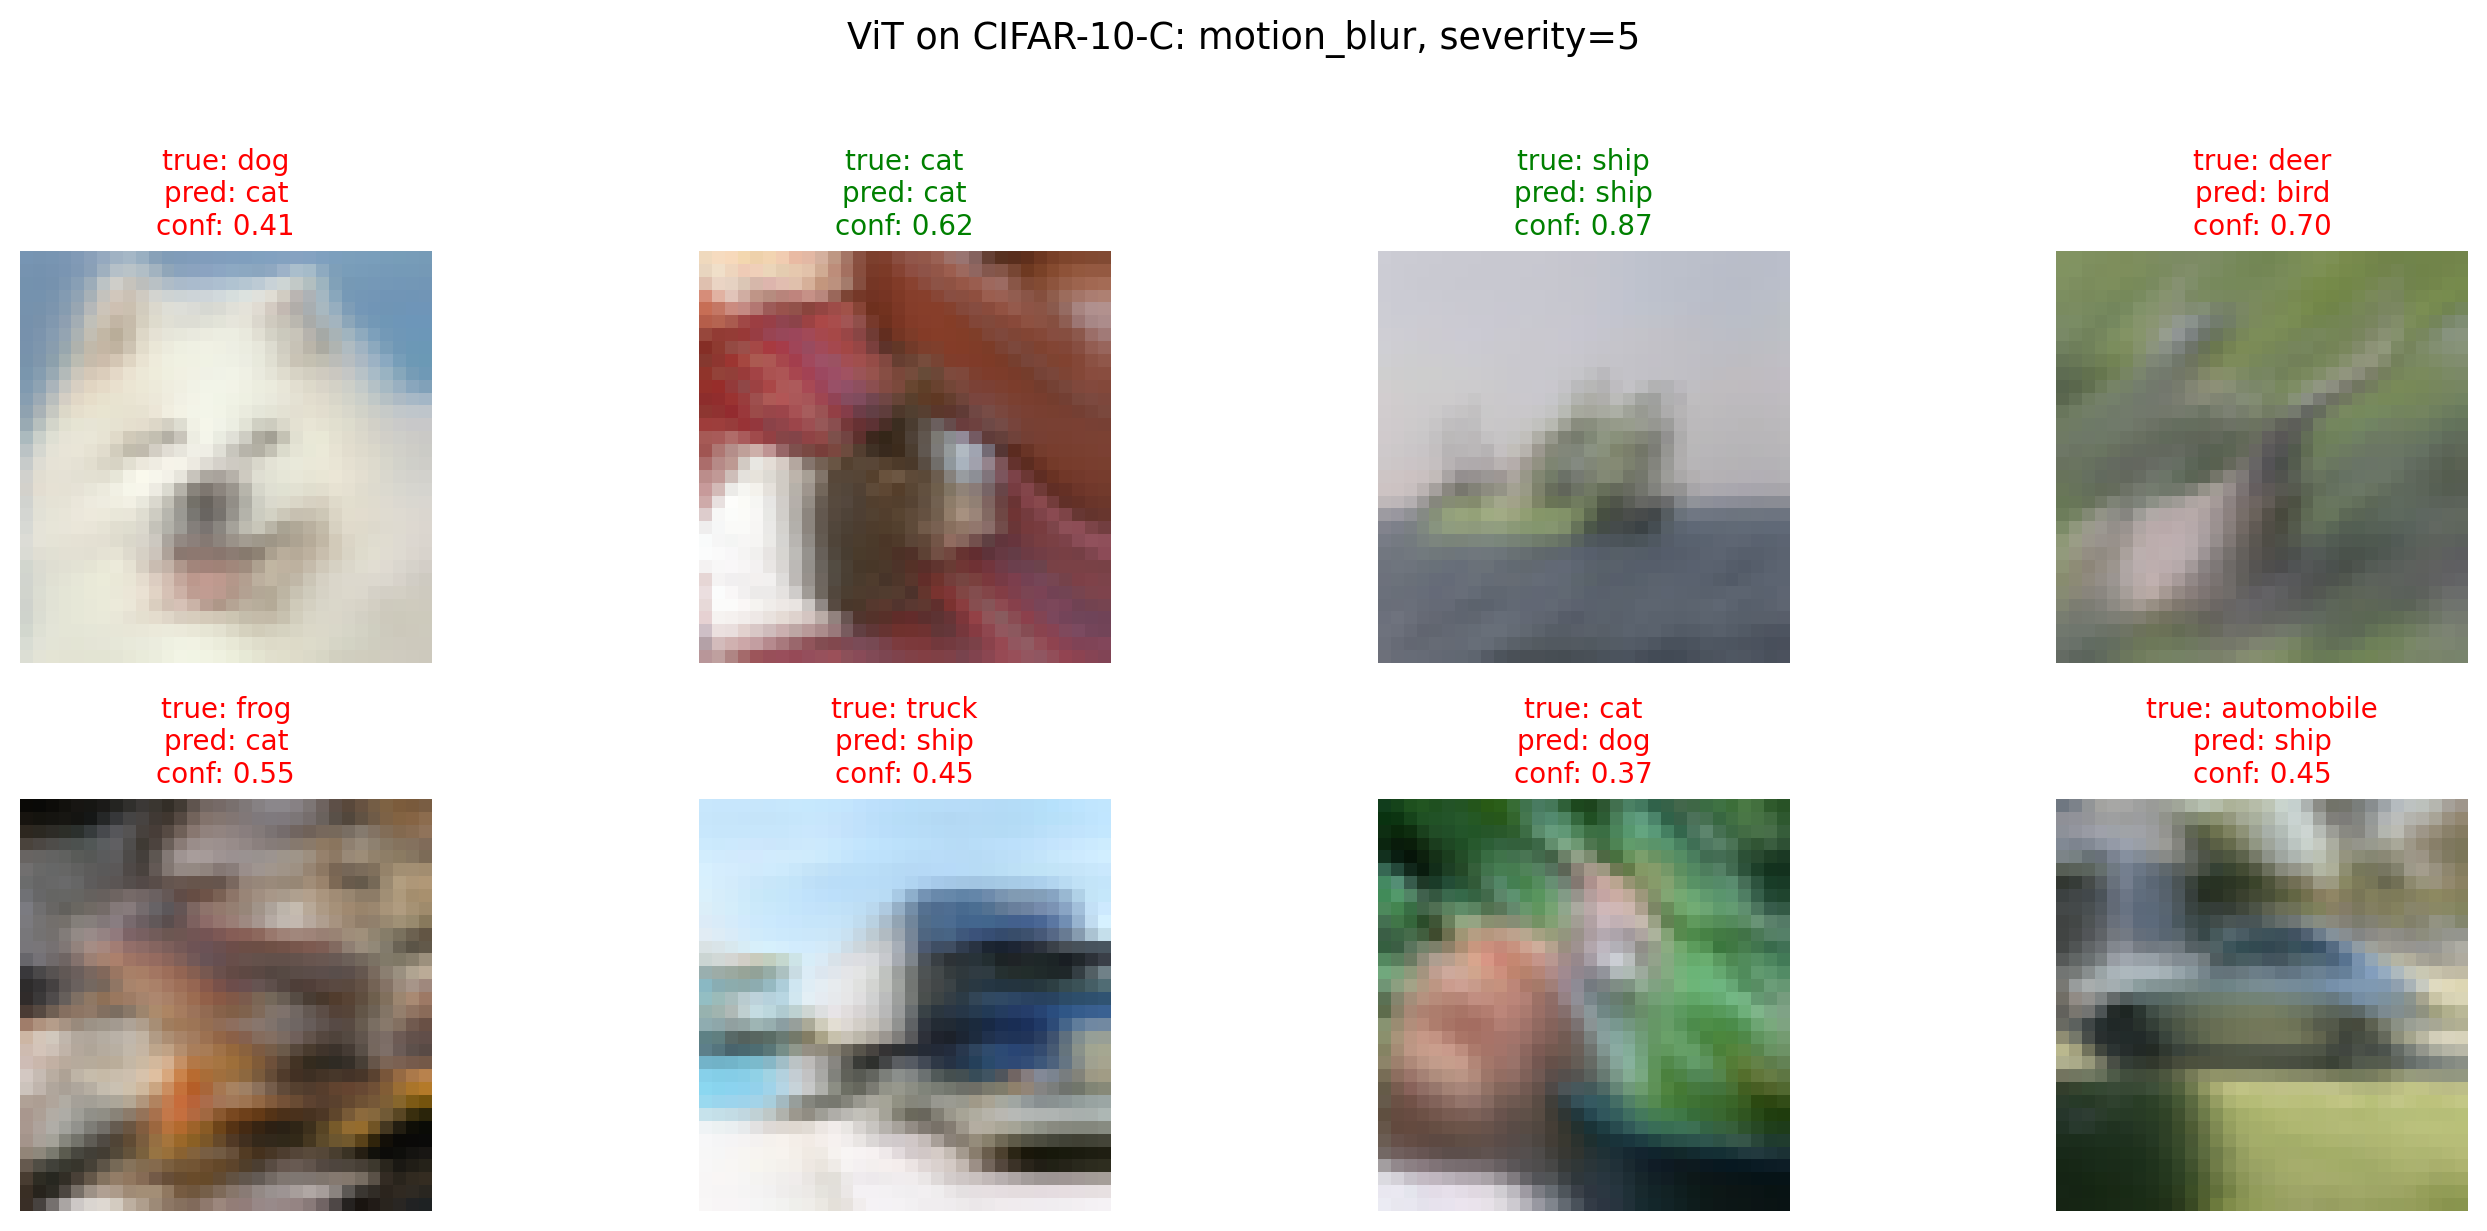

In [11]:
visualize_vit_predictions_on_c10c(
    vit_stable_model,
    c10c_dir,
    corruption="motion_blur",
    severity=5,
    n=8
)

In [12]:
@torch.no_grad()
def corruption_breakdown_vit(model, c10c_dir, severity=5, batch_size=256):
    model.eval()
    accs = {}

    for corr in C10C_CORRUPTIONS:
        x_raw, y = load_c10c_corruption(c10c_dir, corr, severity)
        ds = CIFAR10CDataset(x_raw, y, transform=test_tf)
        dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

        correct, total = 0, 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=-1)
            correct += (pred == yb).sum().item()
            total += yb.numel()

        accs[corr] = correct / total

    return accs

In [13]:
def plot_corruption_breakdown(accs, title="ViT robustness by corruption type"):
    items = sorted(accs.items(), key=lambda kv: kv[1])
    names = [k for k, _ in items]
    vals = [v for _, v in items]

    plt.figure(figsize=(10, 5),dpi=500)
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), names, rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [14]:
accs_vit = corruption_breakdown_vit(vit_stable_model, c10c_dir, severity=5)

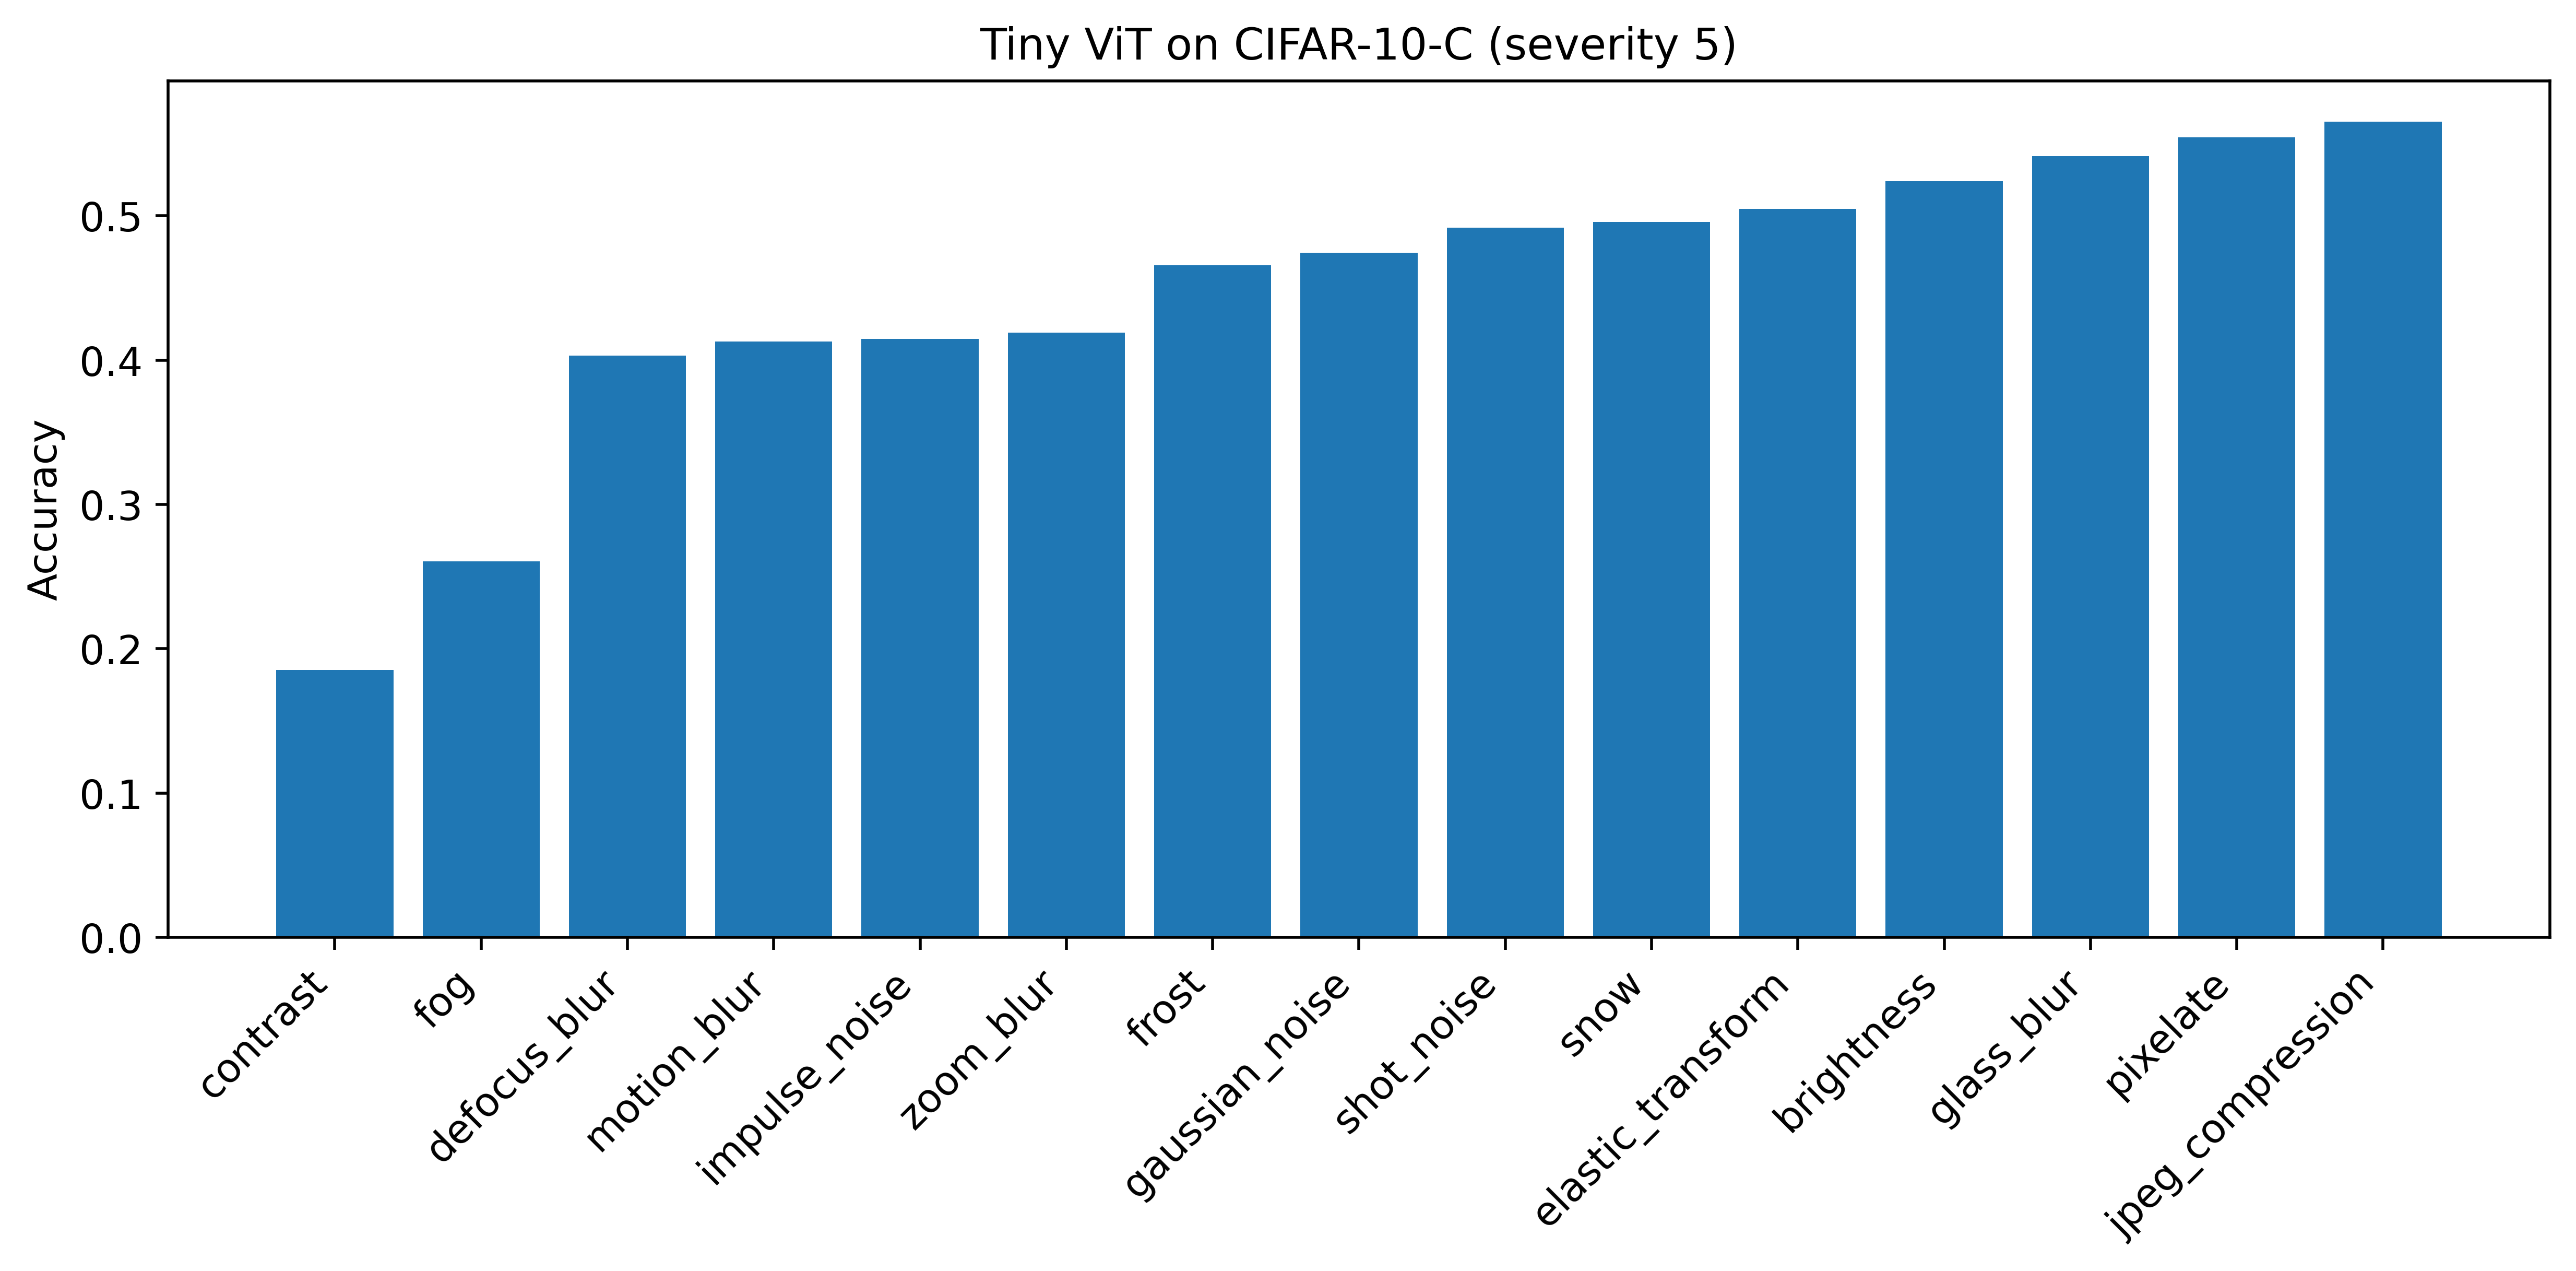

In [15]:
plot_corruption_breakdown(accs_vit, title="Tiny ViT on CIFAR-10-C (severity 5)")

In [16]:
def plot_two_corruption_breakdowns(accs_a, accs_b, label_a="stable", label_b="unstable"):
    names = sorted(accs_a.keys())
    vals_a = [accs_a[k] for k in names]
    vals_b = [accs_b[k] for k in names]

    x = np.arange(len(names))
    w = 0.38

    plt.figure(figsize=(11, 5),dpi=500)
    plt.bar(x - w/2, vals_a, width=w, label=label_a)
    plt.bar(x + w/2, vals_b, width=w, label=label_b)

    plt.xticks(x, names, rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title("ViT robustness by corruption type")
    plt.legend()
    plt.tight_layout()
    plt.show()

accs_vit_stable = corruption_breakdown_vit(vit_stable_model, c10c_dir, severity=5)
accs_vit_unstable = corruption_breakdown_vit(vit_unstable_model, c10c_dir, severity=5)

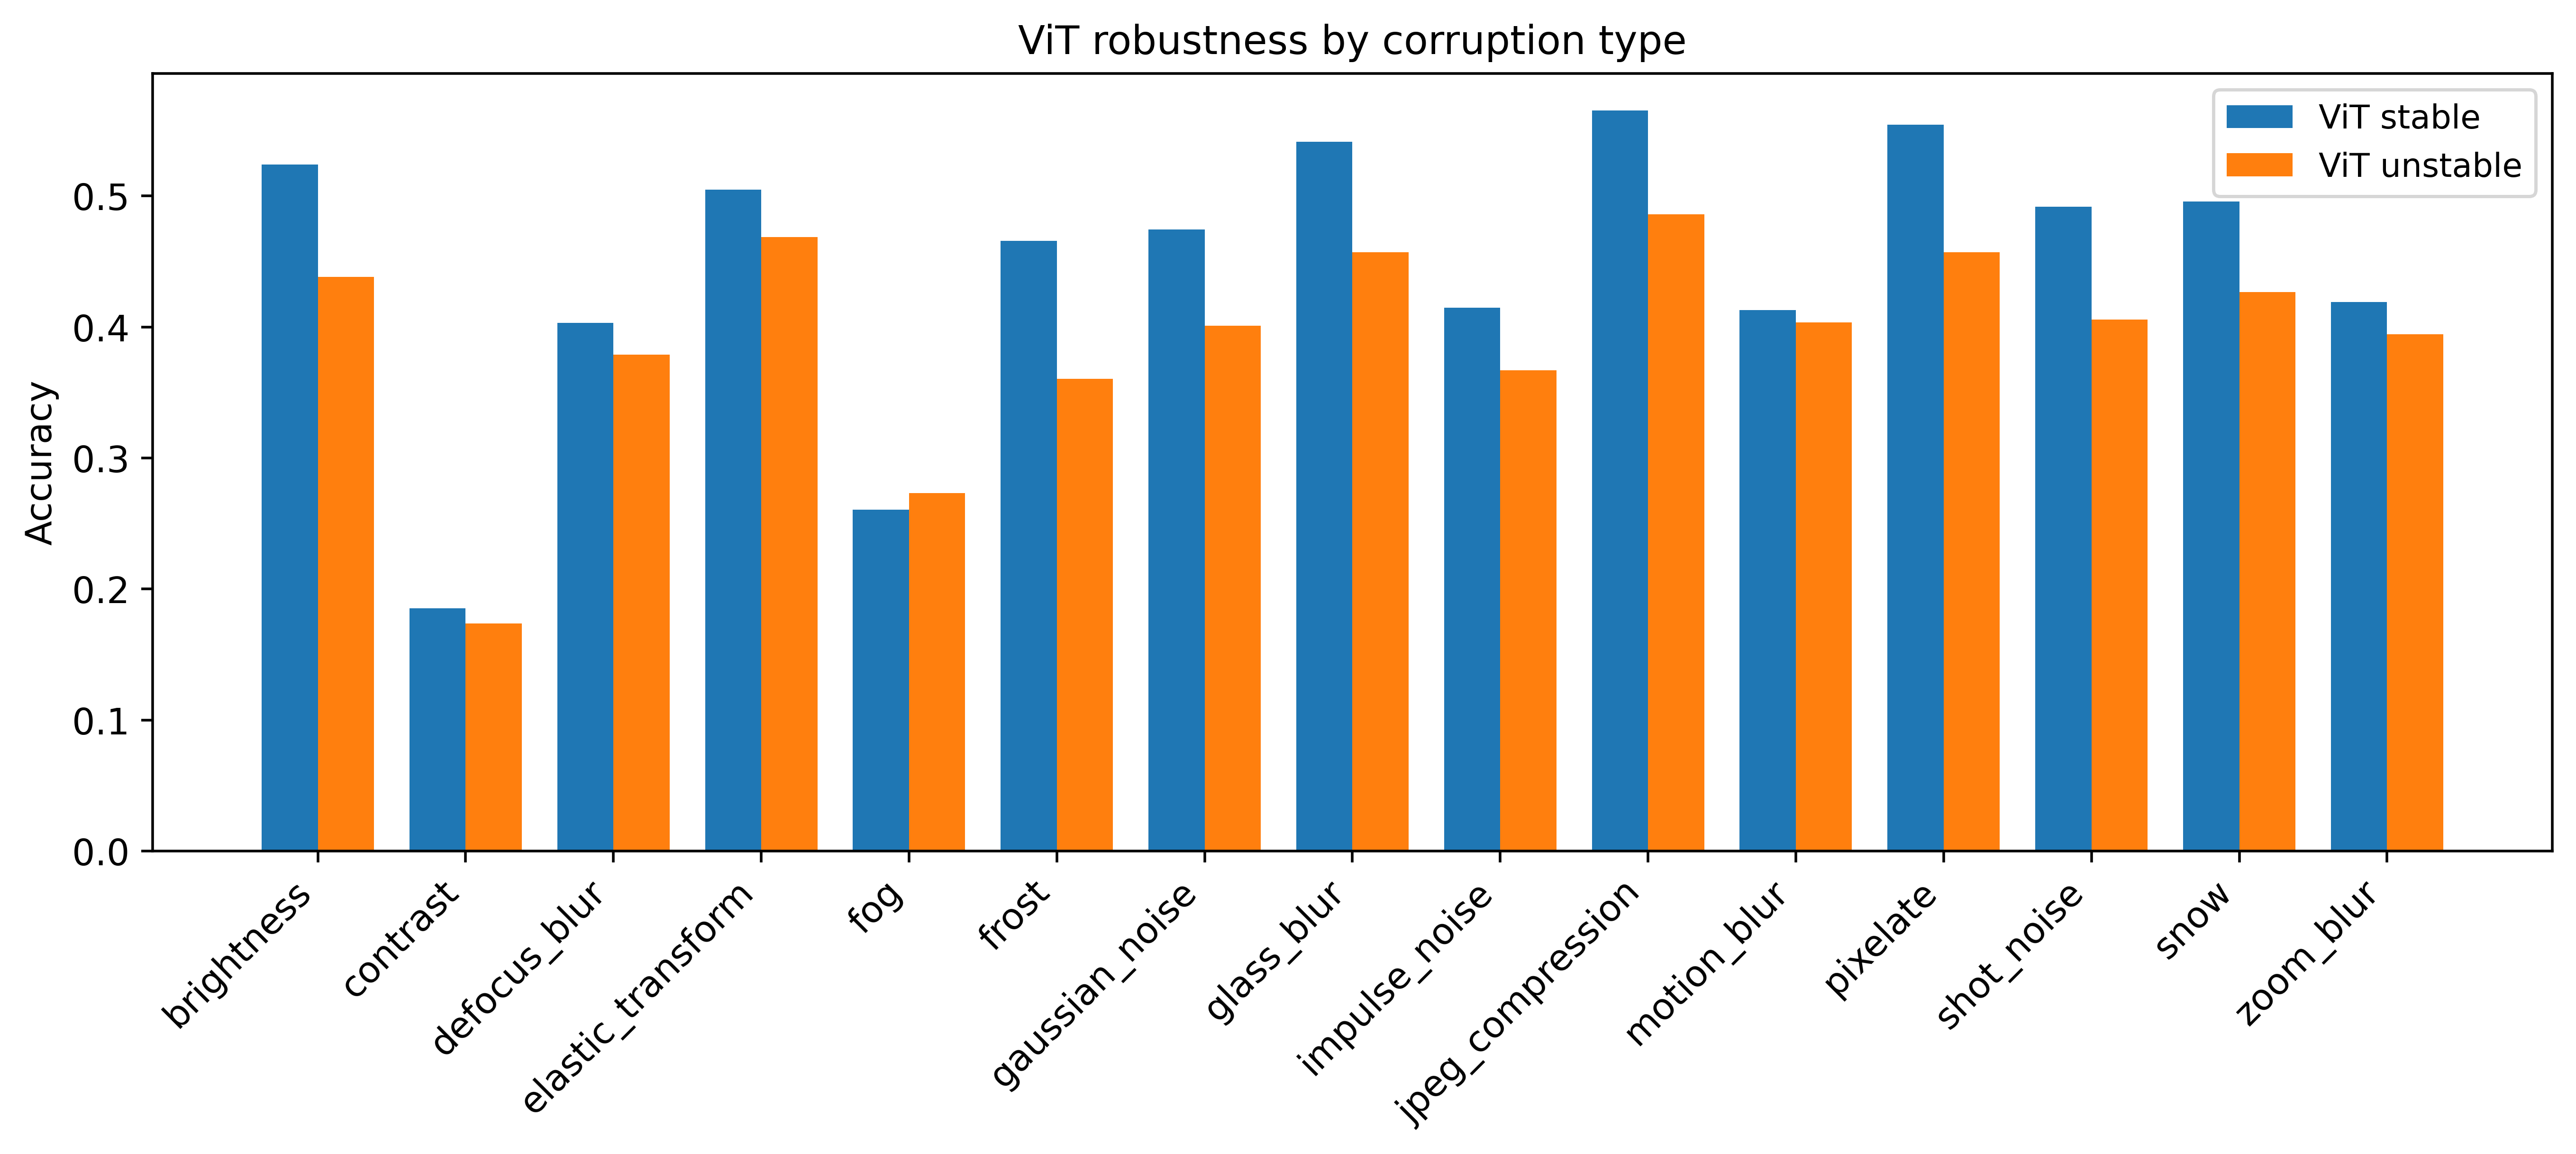

In [17]:
plot_two_corruption_breakdowns(
    accs_vit_stable,
    accs_vit_unstable,
    label_a="ViT stable",
    label_b="ViT unstable"
)

In [18]:
attention_maps = {}

def get_attention_hook(name):
    def hook(module, input, output):
        # output structure may vary depending on version
        attention_maps[name] = output
    return hook

import timm

vit_timm = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
).to(device)


@torch.no_grad()
def vit_patch_occlusion_map(model, img_tensor, target_class=None, patch=4):
    """
    img_tensor: [3,32,32] normalized
    returns heatmap [H/patch, W/patch]
    """
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)

    logits = model(x)
    if target_class is None:
        target_class = logits.argmax(dim=-1).item()

    base_score = logits[0, target_class].item()

    H, W = img_tensor.shape[1], img_tensor.shape[2]
    gh, gw = H // patch, W // patch
    heat = np.zeros((gh, gw), dtype=np.float32)

    for i in range(gh):
        for j in range(gw):
            x_occ = x.clone()
            h0, h1 = i * patch, (i + 1) * patch
            w0, w1 = j * patch, (j + 1) * patch

            # zero-out patch in normalized space
            x_occ[:, :, h0:h1, w0:w1] = 0.0

            score = model(x_occ)[0, target_class].item()
            heat[i, j] = base_score - score

    return heat

In [19]:
def show_patch_occlusion_map(model, c10c_dir, corruption="gaussian_noise", severity=5, idx=0, patch=4):
    x_raw, y = load_c10c_corruption(c10c_dir, corruption, severity)

    img_pil = torchvision.transforms.functional.to_pil_image(x_raw[idx])
    img_tensor = test_tf(img_pil)  # normalized

    heat = vit_patch_occlusion_map(model, img_tensor, patch=patch)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4),dpi=500)

    axes[0].imshow(unnormalize(img_tensor),interpolation='bicubic')
    axes[0].set_title(f"Input: {corruption}, sev={severity}")
    axes[0].axis("off")

    axes[1].imshow(unnormalize(img_tensor),interpolation='bicubic')
    axes[1].imshow(
        heat,
        cmap="inferno",
        alpha=0.55,
        extent=(0, 32, 32, 0),
        interpolation="nearest"
    )
    axes[1].set_title("Patch occlusion sensitivity")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

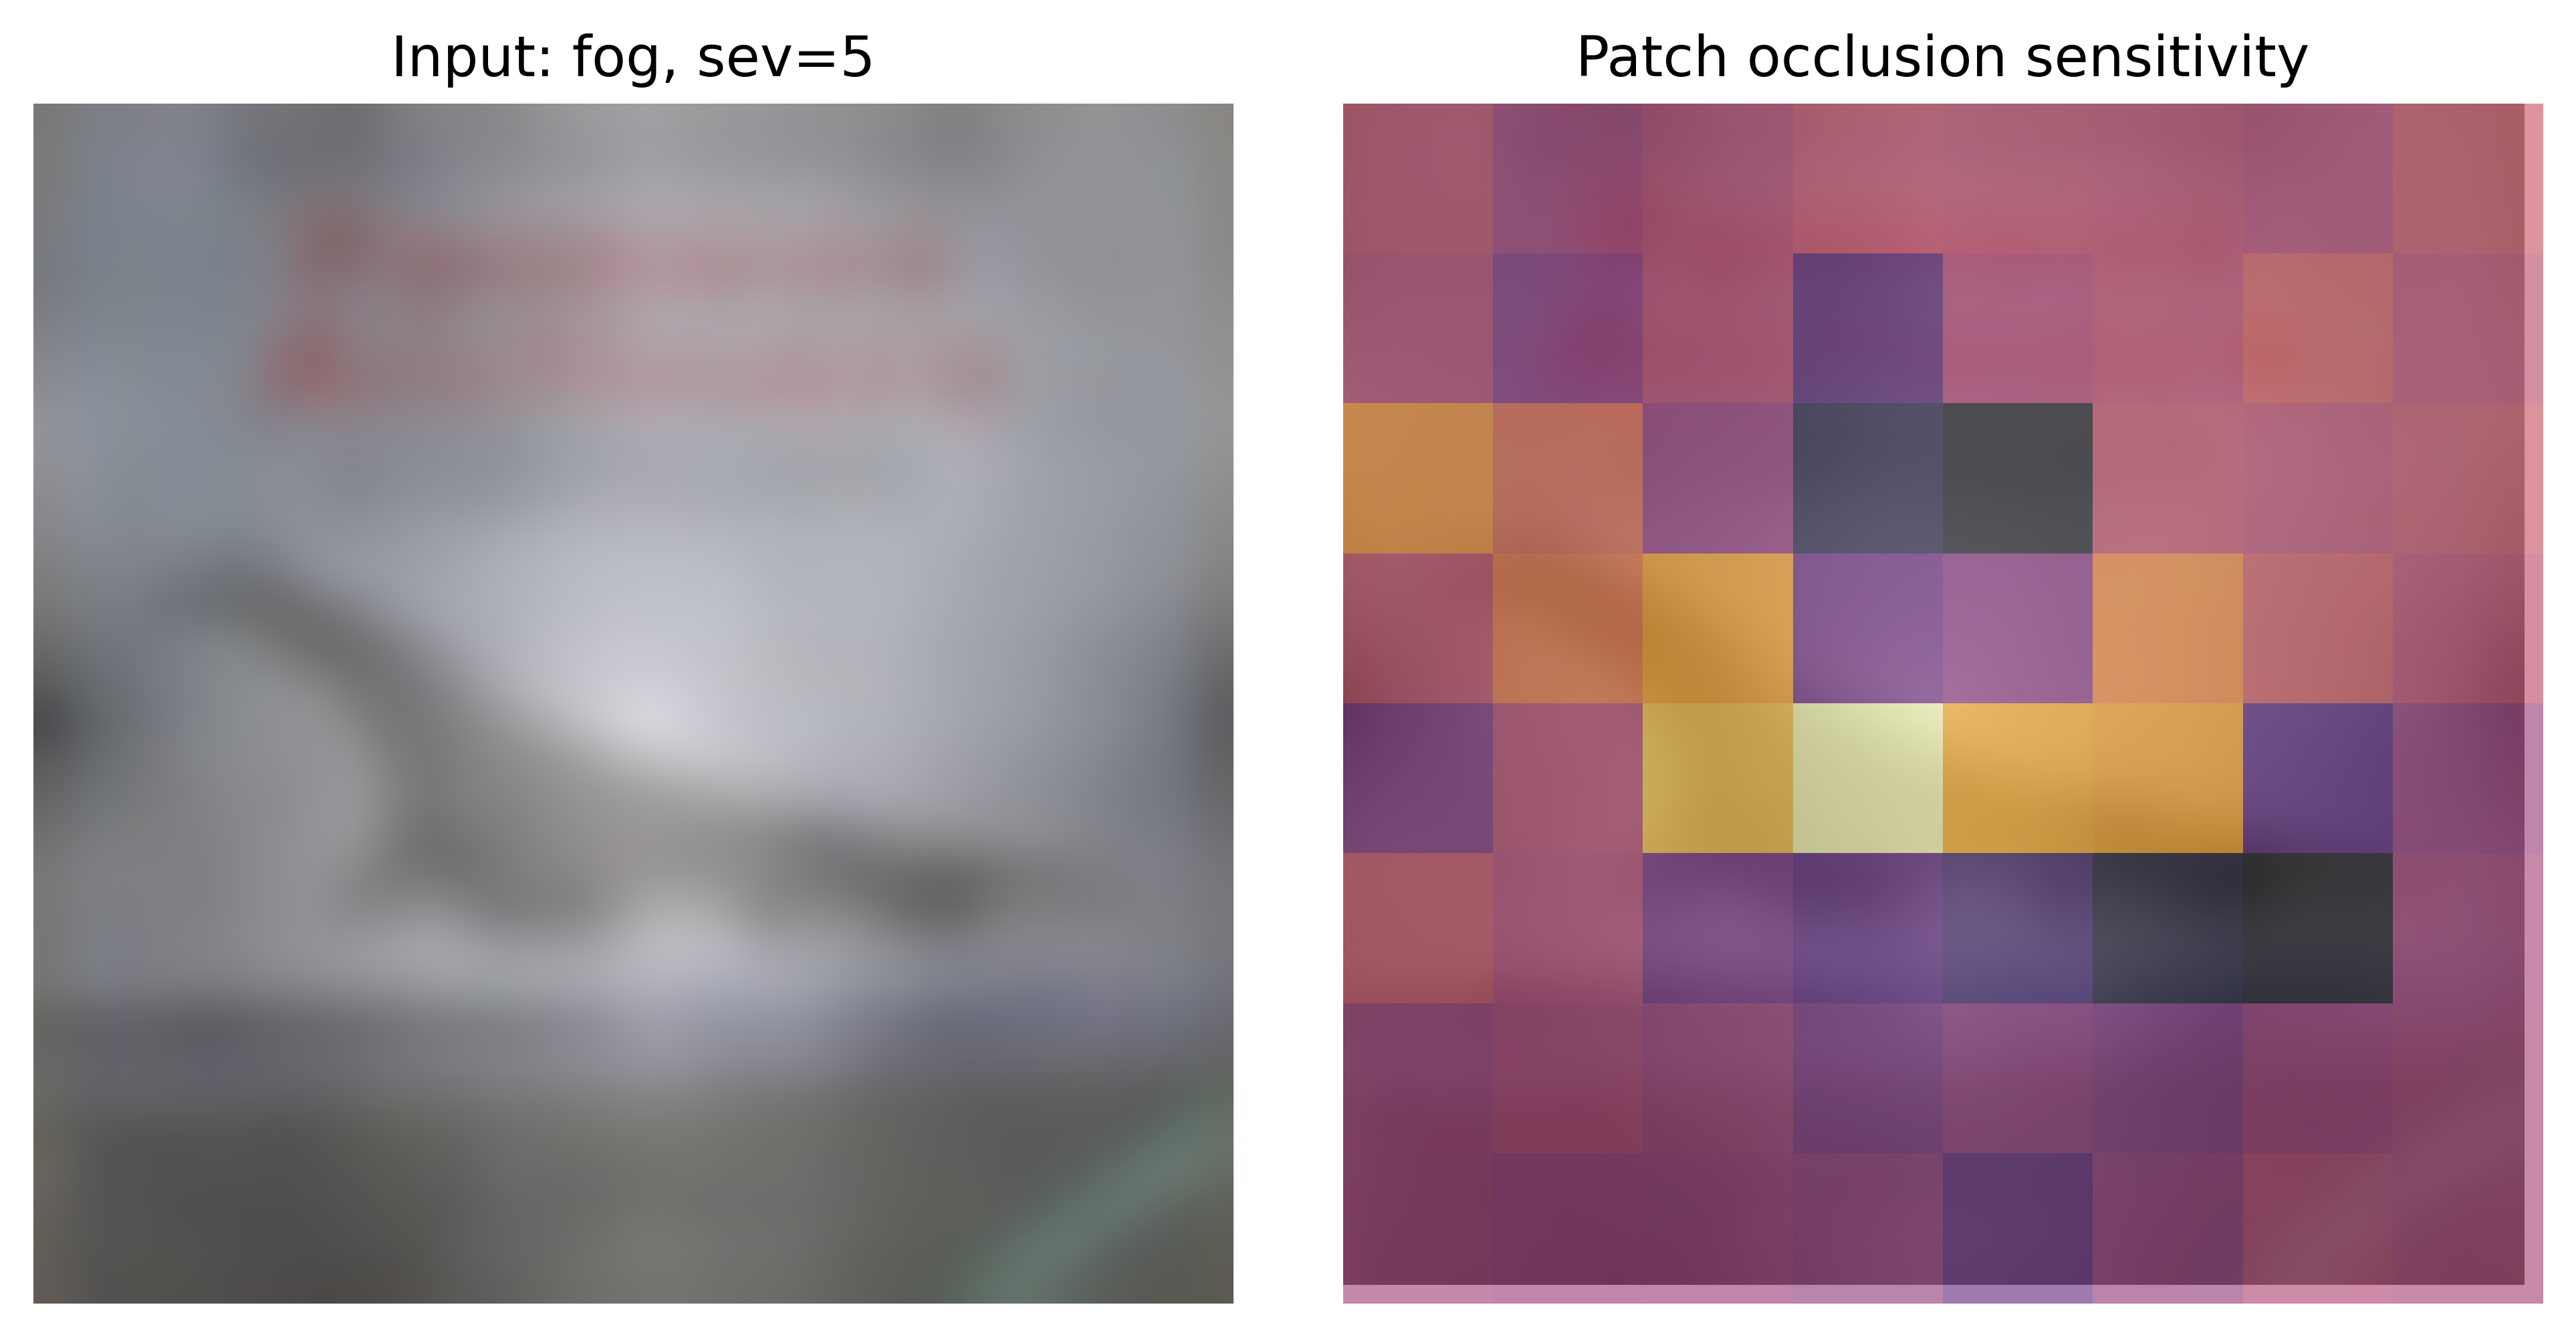

In [20]:
show_patch_occlusion_map(
    vit_stable_model,
    c10c_dir,
    corruption="fog",
    severity=5,
    idx=3,
    patch=4
)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multi_corruption_overlay(logs_dict, outfile="appendix_multi_corr.pdf"):
    """
    logs_dict = {
        "fog": logs_fog,
        "gaussian_noise": logs_noise,
        "blur": logs_blur,
    }
    """

    plt.figure(figsize=(6.8, 5.2))

    for name, logs in logs_dict.items():
        S = np.array(logs["sigma_mean"])
        R = np.array(logs["c10c_acc_mean"])

        plt.scatter(S, R, s=45, alpha=0.75, label=name)

        # optional quadratic fit
        coeffs = np.polyfit(S, R, 2)
        S_fit = np.linspace(S.min(), S.max(), 200)
        R_fit = np.polyval(coeffs, S_fit)

        plt.plot(S_fit, R_fit, linewidth=1.5)

    plt.xlabel("Sensitivity")
    plt.ylabel(r"Robustness $\mathcal{R}_5$")
    plt.title("Sensitivity–robustness structure across corruption types")

    plt.legend(frameon=False)

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(outfile, format="pdf", bbox_inches="tight")
    plt.show()

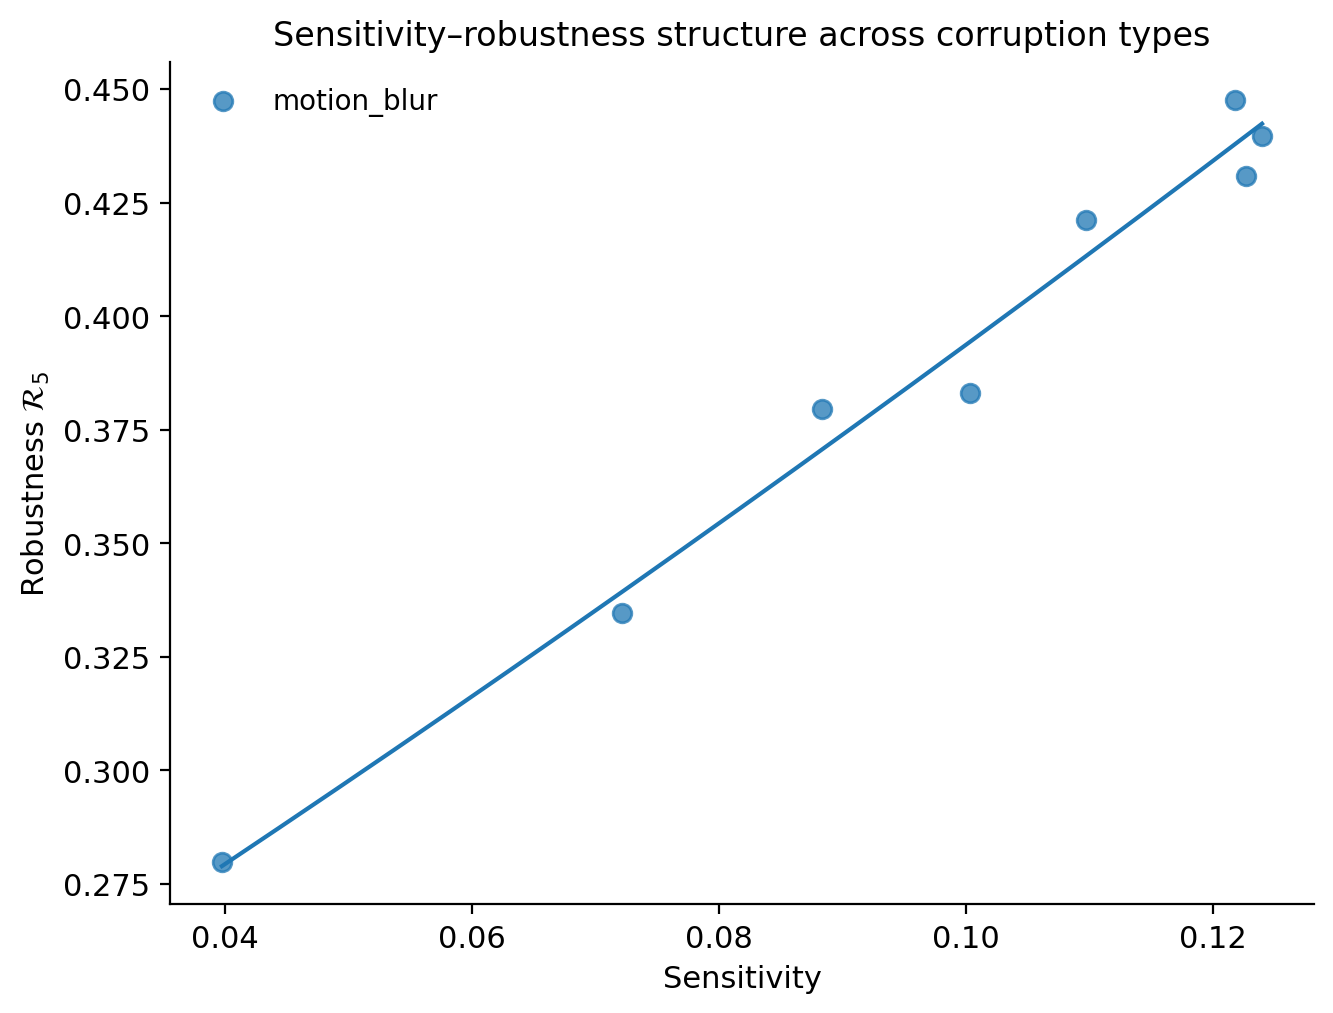

In [22]:
logs_dict = {
    "motion_blur": vit_stable_logs
}

plot_multi_corruption_overlay(logs_dict)

In [23]:
def quadratic_fit(sigmas, accs):
    sigmas = np.asarray(sigmas, float)
    accs = np.asarray(accs, float)
    a, b, c = np.polyfit(sigmas, accs, deg=2)
    return float(a), float(b), float(c)

def sensitivity_optimal_band(a, b, c, eta=0.01):
    assert a < 0, "Need a < 0 for concave fit."
    s_star = -b / (2*a)
    R_star = a*s_star*s_star + b*s_star + c
    thr = (1-eta) * R_star

    # Solve a s^2 + b s + c = thr
    A, B, C = a, b, (c - thr)
    disc = B*B - 4*A*C
    disc = max(disc, 0.0)
    r1 = (-B - math.sqrt(disc)) / (2*A)
    r2 = (-B + math.sqrt(disc)) / (2*A)
    lo, hi = (min(r1, r2), max(r1, r2))
    return float(s_star), float(R_star), (float(lo), float(hi))

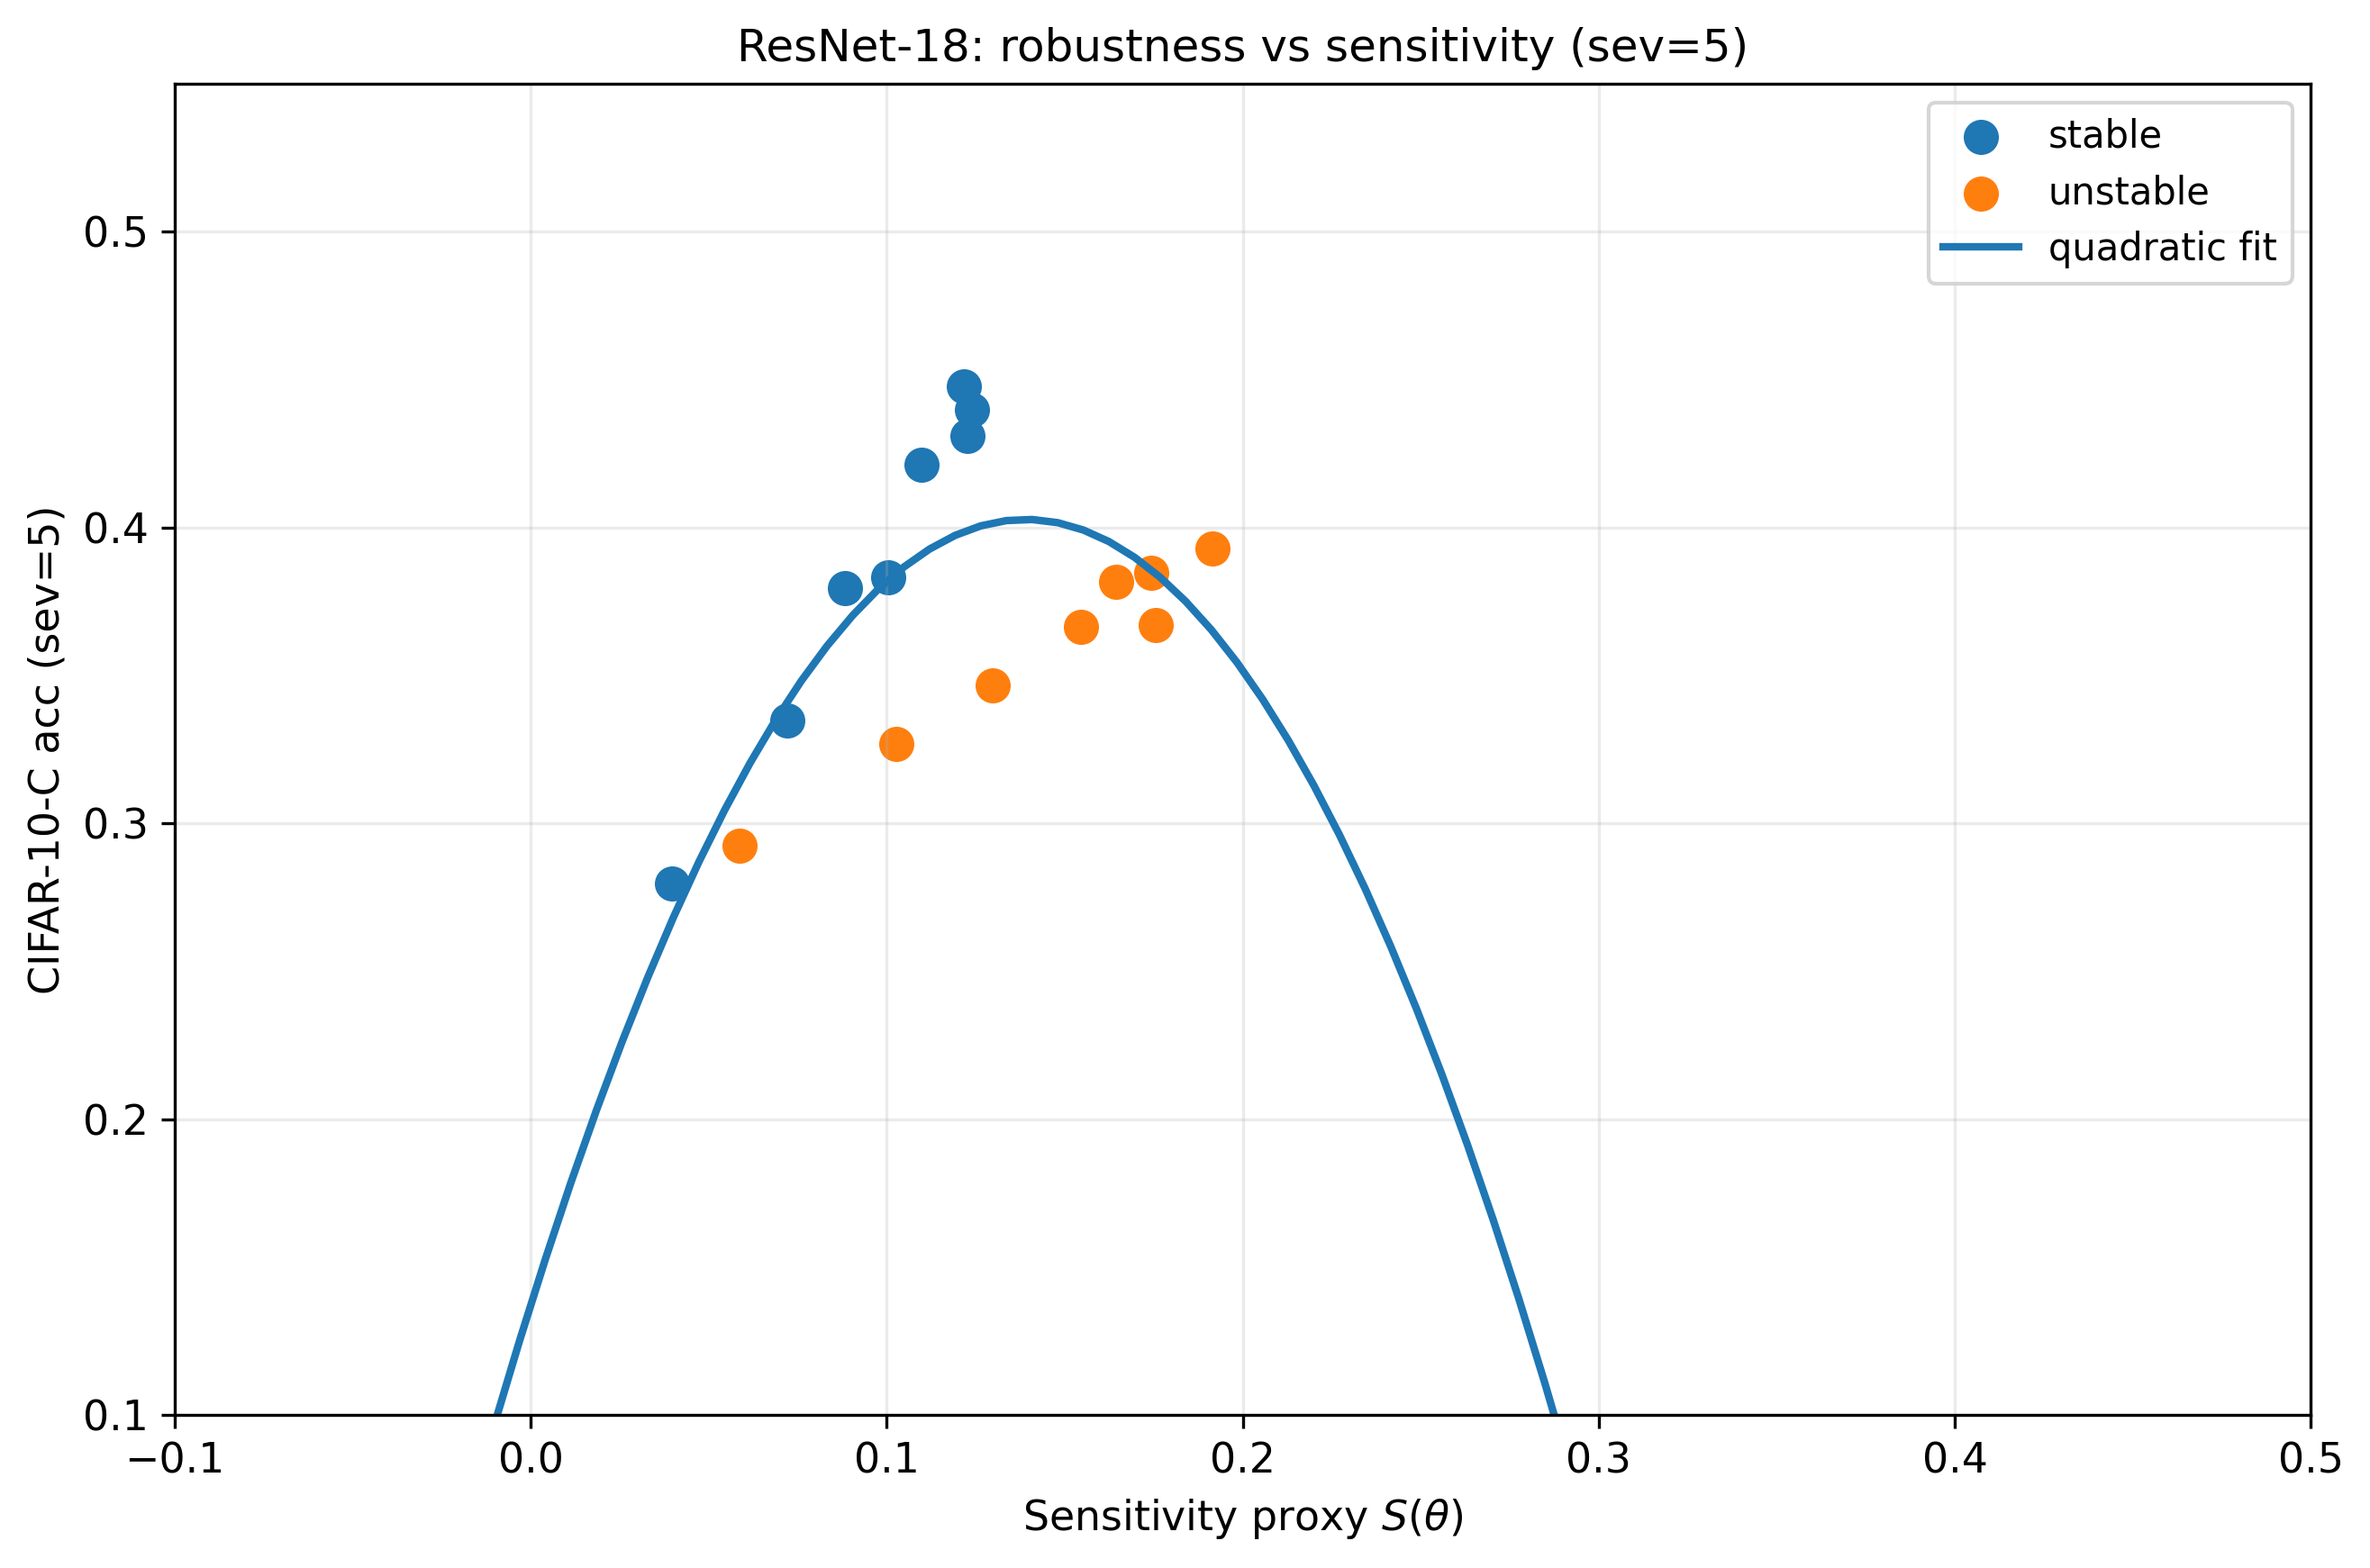

a,b,c = -13.733350548999704 3.819513485962549 0.13713227805070788
sigma*=0.139, R*=0.402703, 1% band=[0.122,0.156]


In [24]:
def plot_quadratic_fit(stable_logs, unstable_logs, title="ResNet-18: robustness vs sensitivity (sev=5)"):
    sig_st = np.asarray(stable_logs["sigma_mean"])
    sig_un = np.asarray(unstable_logs["sigma_mean"])
    rob_st = np.asarray(stable_logs["c10c_acc_mean"])
    rob_un = np.asarray(unstable_logs["c10c_acc_mean"])

    sig = np.concatenate([sig_st, sig_un])
    rob = np.concatenate([rob_st, rob_un])

    a,b,c = quadratic_fit(sig, rob)
    s_grid = np.linspace(sig.min()-1, sig.max()+1, 300)
    r_grid = a*s_grid**2 + b*s_grid + c

    xmin, xmax = sig.min(), sig.max()
    x_plot = np.linspace(xmin - 0.02, xmax + 0.02, 200)

    plt.figure(figsize=(10.2,6.4),dpi=300)
    plt.scatter(sig_st, rob_st, s=70, label="stable")
    plt.scatter(sig_un, rob_un, s=70, label="unstable")
    plt.xlim(-.1,.5)
    plt.ylim(0.1, 0.55)   # adjust based on your data
    plt.plot(s_grid, r_grid, label="quadratic fit")
    plt.xlabel(r"Sensitivity proxy $S(\theta)$")
    plt.ylabel("CIFAR-10-C acc (sev=5)")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.savefig("fig1_sensitivity_quadratic.pdf", bbox_inches="tight")
    plt.show()

    print("a,b,c =", a,b,c)
    if a < 0:
        s_star, R_star, band1 = sensitivity_optimal_band(a,b,c,eta=0.01)
        print(f"sigma*={s_star:.3f}, R*={R_star:.6f}, 1% band=[{band1[0]:.3f},{band1[1]:.3f}]")

plot_quadratic_fit(vit_stable_logs, vit_unstable_logs)

In [25]:
vit_sig_all = np.array(vit_stable_logs["sigma_mean"] + vit_unstable_logs["sigma_mean"])
vit_rob_all = np.array(vit_stable_logs["c10c_acc_mean"] + vit_unstable_logs["c10c_acc_mean"])

a, b, c = quadratic_fit(vit_sig_all, vit_rob_all)
print("ViT quadratic coefficients:", a, b, c)

if a < 0:
    s_star, R_star, band = sensitivity_optimal_band(a, b, c, eta=0.01)
    print(f"ViT sigma*={s_star:.6f}, R*={R_star:.6f}, band={band}")
else:
    print("Fit is not concave; no optimal band yet.")

ViT quadratic coefficients: -13.733350548999704 3.819513485962549 0.13713227805070788
ViT sigma*=0.139060, R*=0.402703, band=(0.12193583142592784, 0.1561837339587008)


In [26]:
import numpy as np

def compute_overshoot_drop(logs, a, b, c, band_right):
    S = np.array(logs["sigma_mean"], dtype=float)
    R = np.array(logs["c10c_acc_mean"], dtype=float)

    # points after overshoot (right of band)
    mask = S > band_right

    if np.sum(mask) == 0:
        return {
            "drop_abs": None,
            "drop_pct": None,
            "R_worst": None
        }

    # worst robustness after overshoot
    R_worst = np.min(R[mask])

    # quadratic optimum
    S_star = -b / (2 * a)
    R_star = a * S_star**2 + b * S_star + c

    drop_abs = R_star - R_worst
    drop_pct = 100.0 * drop_abs / R_star

    return {
        "drop_abs": drop_abs,
        "drop_pct": drop_pct,
        "R_worst": R_worst
    }

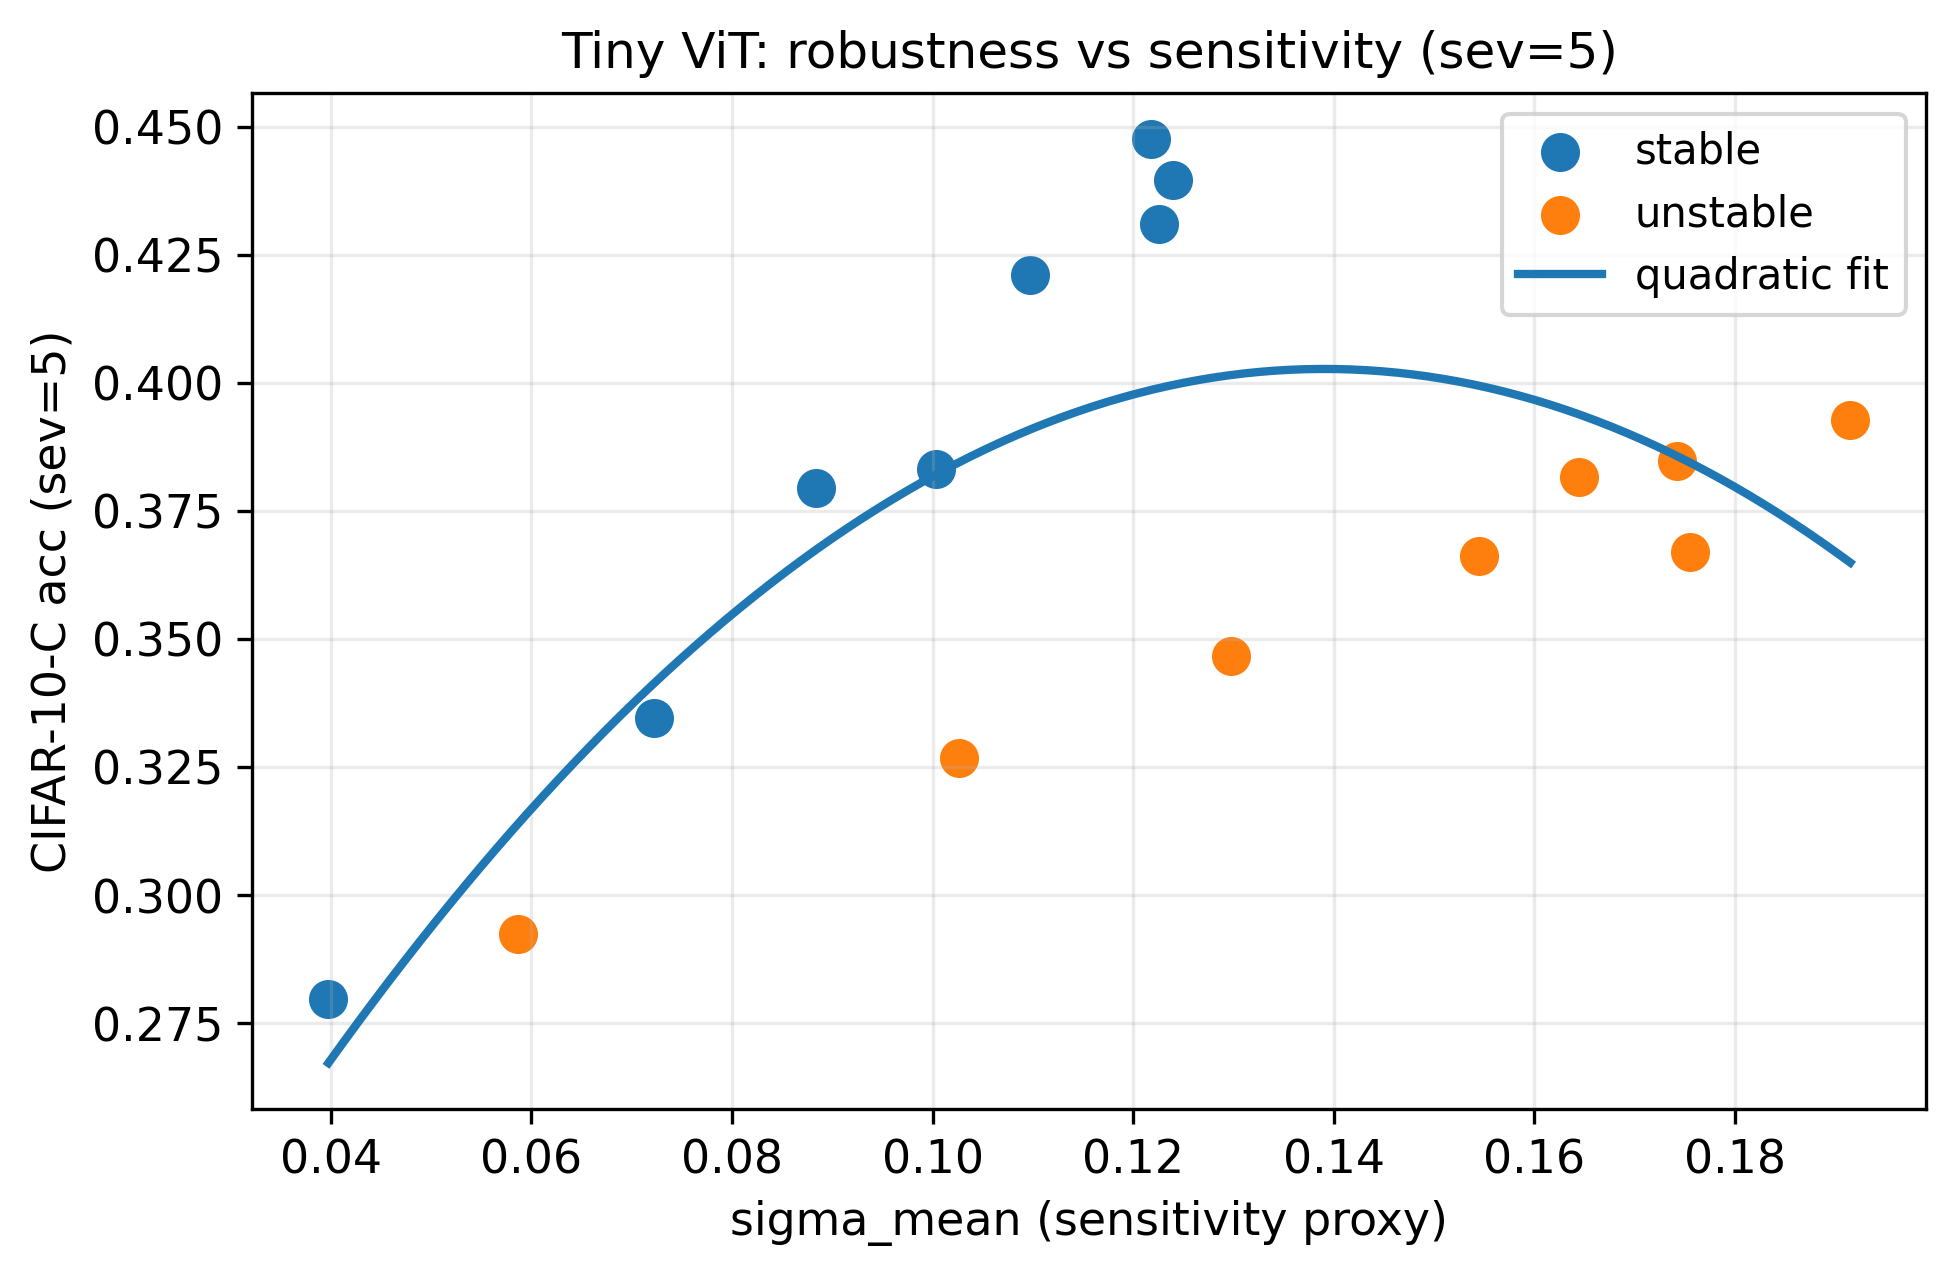

In [27]:
def plot_vit_quadratic(stable_logs, unstable_logs, title="Tiny ViT: robustness vs sensitivity (sev=5)"):
    sig_st = np.asarray(stable_logs["sigma_mean"])
    sig_un = np.asarray(unstable_logs["sigma_mean"])
    rob_st = np.asarray(stable_logs["c10c_acc_mean"])
    rob_un = np.asarray(unstable_logs["c10c_acc_mean"])

    sig = np.concatenate([sig_st, sig_un])
    rob = np.concatenate([rob_st, rob_un])

    a, b, c = quadratic_fit(sig, rob)

    s_grid = np.linspace(sig.min(), sig.max(), 300)
    r_grid = a*s_grid**2 + b*s_grid + c

    plt.figure(figsize=(7.2, 4.4),dpi=300)
    plt.scatter(sig_st, rob_st, s=70, label="stable")
    plt.scatter(sig_un, rob_un, s=70, label="unstable")
    plt.plot(s_grid, r_grid, linewidth=2, label="quadratic fit")
    plt.xlabel("sigma_mean (sensitivity proxy)")
    plt.ylabel("CIFAR-10-C acc (sev=5)")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.show()

plot_vit_quadratic(vit_stable_logs, vit_unstable_logs)

In [28]:
def plot_band_and_robustness_advanced(
    stable_logs, unstable_logs,
    title="ResNet-18: Sensitivity band and severe-corruption robustness (CIFAR-10-C sev=5)",
    eta=0.01,
):
    steps = np.asarray(stable_logs["step"])
    sig_st = np.asarray(stable_logs["sigma_mean"])
    sig_un = np.asarray(unstable_logs["sigma_mean"])
    rob_st = np.asarray(stable_logs["c10c_acc_mean"])
    rob_un = np.asarray(unstable_logs["c10c_acc_mean"])
    rob_st_sd = np.asarray(stable_logs["c10c_acc_std"])
    rob_un_sd = np.asarray(unstable_logs["c10c_acc_std"])

    # Fit quadratic on pooled points (optional: only on unstable; here pooled)
    sig_all = np.concatenate([sig_st, sig_un])
    rob_all = np.concatenate([rob_st, rob_un])
    a,b,c = quadratic_fit(sig_all, rob_all)

    # If fit is not concave, still plot trajectories without band
    band = None
    s_star = None
    if a < 0:
        s_star, R_star, band = sensitivity_optimal_band(a,b,c,eta=eta)

    fig = plt.figure(figsize=(14.4, 12.2),dpi=300)
    gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.4], hspace=0.22)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[1,0], sharex=ax1)

    # --- top: sensitivity trajectories ---
    if band is not None:
        lo, hi = band
        ax1.axhspan(lo, hi, alpha=0.18, label=f"{int(eta*100)}% optimal band [{lo:.1f},{hi:.1f}]")
        ax1.axhline(s_star, linestyle="--", linewidth=1.6, label=r"$\sigma^*$")

    ax1.plot(steps, sig_st, marker="o", label="stable")
    ax1.plot(steps, sig_un, marker="o", label="unstable")
    ax1.set_ylabel(r"Sensitivity $S(\theta)$ (sigma_mean)")
    ax1.set_title(title)
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", frameon=True)

    # annotate entry/exit for unstable
    if band is not None:
        inside = (sig_un >= lo) & (sig_un <= hi)
        if inside.any():
            idxs = np.where(inside)[0]
            enter_i, exit_i = idxs[0], idxs[-1]
            ax1.scatter([steps[enter_i]], [sig_un[enter_i]], s=80, zorder=5)
            ax1.annotate("enters band", xy=(steps[enter_i], sig_un[enter_i]),
                         xytext=(10, 16), textcoords="offset points",
                         arrowprops=dict(arrowstyle="->", lw=1.2))
            ax1.scatter([steps[exit_i]], [sig_un[exit_i]], s=80, zorder=5)
            ax1.annotate("last in band", xy=(steps[exit_i], sig_un[exit_i]),
                         xytext=(10, -22), textcoords="offset points",
                         arrowprops=dict(arrowstyle="->", lw=1.2))
            ax1.text(0.84, 0.92, "overshoot", transform=ax1.transAxes, va="top", alpha=0.9)

    # --- bottom: robustness trajectories ---
    ax2.plot(steps, rob_st, marker="o", label="stable sev=5")
    ax2.fill_between(steps, rob_st-rob_st_sd, rob_st+rob_st_sd, alpha=0.18)

    ax2.plot(steps, rob_un, marker="o", label="unstable sev=5")
    ax2.fill_between(steps, rob_un-rob_un_sd, rob_un+rob_un_sd, alpha=0.18)

    ax2.set_ylabel("CIFAR-10-C acc (sev=5)")
    ax2.set_xlabel("Training Step")
    ax2.grid(True, alpha=0.25)
    ax2.legend(loc="lower right", frameon=True)

    plt.savefig("figure2_resnet_sensitivity_band.pdf", bbox_inches="tight",dpi=300)
    plt.show()

    print("Quadratic fit (pooled): a,b,c =", a,b,c)
    if band is not None:
        print(f"sigma*={s_star:.3f}, band@{eta:.2%}=[{band[0]:.3f},{band[1]:.3f}]")
    else:
        print("Fit not concave; no band drawn.")

#plot_band_and_robustness_advanced(vit_stable_logs, vit_unstable_logs, eta=0.01)

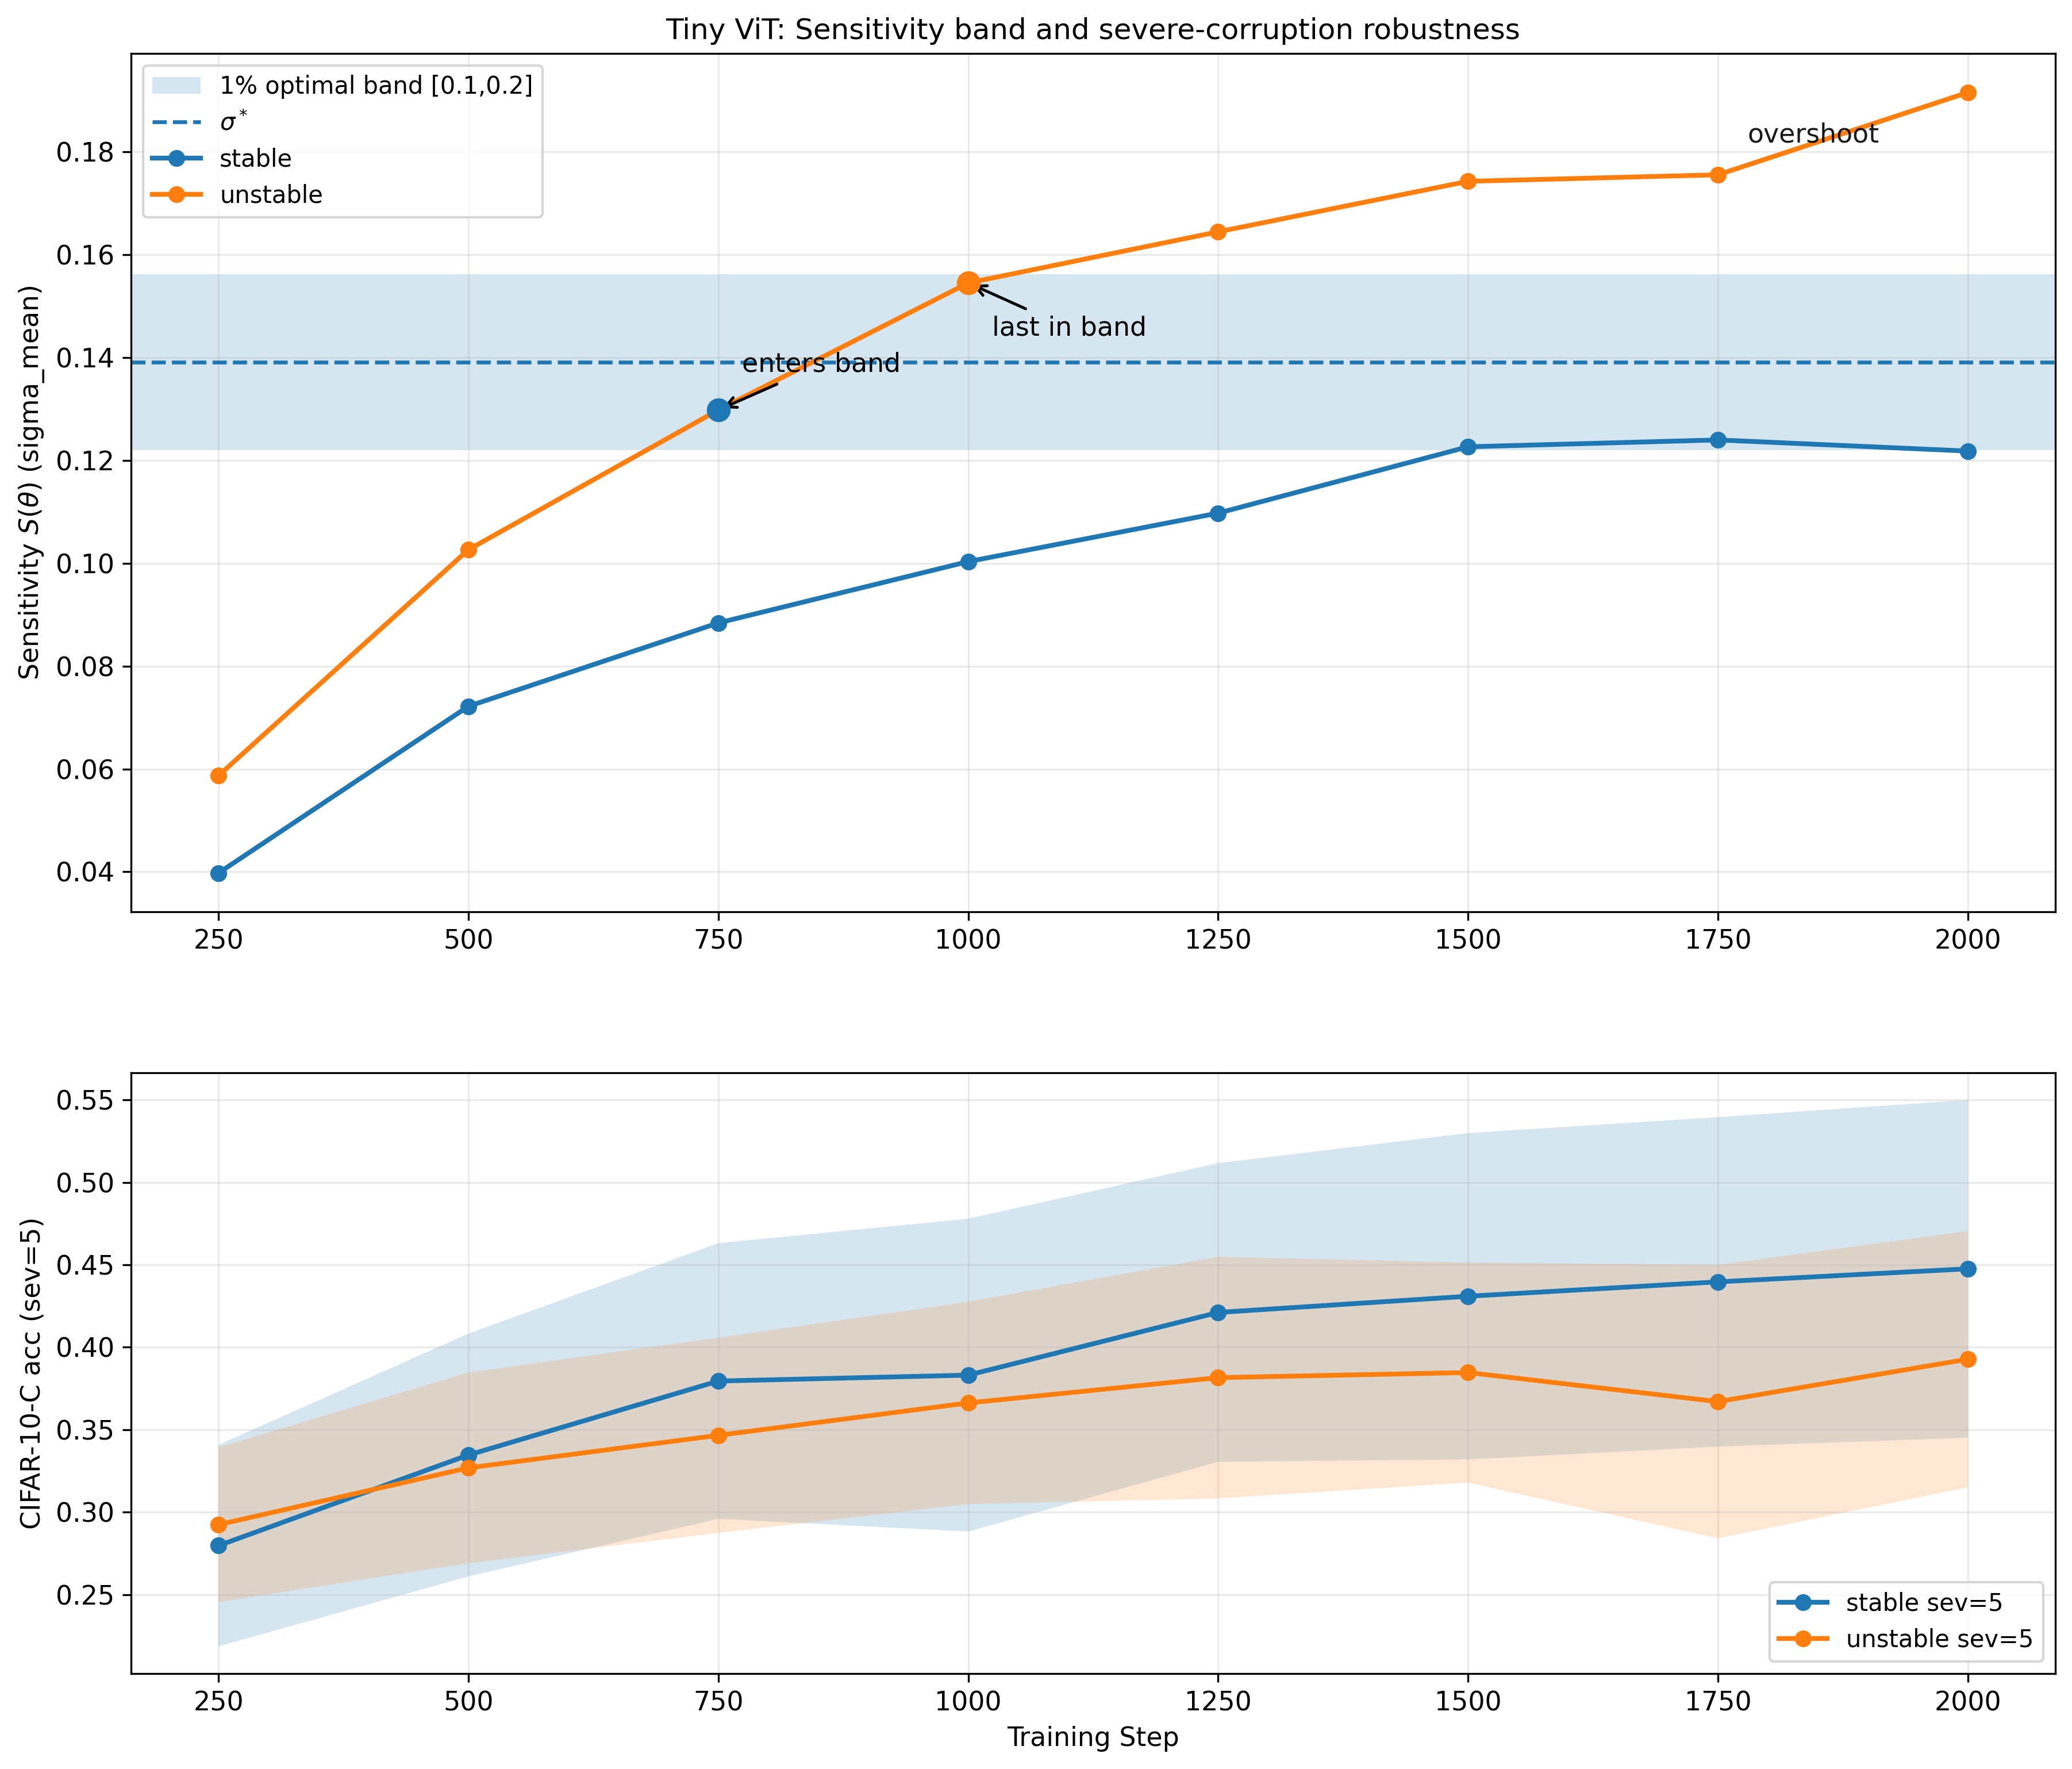

Quadratic fit (pooled): a,b,c = -13.733350548999704 3.819513485962549 0.13713227805070788
sigma*=0.139, band@1.00%=[0.122,0.156]


In [29]:
plot_band_and_robustness_advanced(
    vit_stable_logs,
    vit_unstable_logs,
    title="Tiny ViT: Sensitivity band and severe-corruption robustness",
    eta=0.01,
)

In [30]:
def severity_sweep(model, severities=(1,2,3,4,5)):
    out = {"severity": [], "mean": [], "std": []}
    for s in severities:
        mu, sd, _ = eval_c10c(model, c10c_dir, severity=s)
        out["severity"].append(s)
        out["mean"].append(mu)
        out["std"].append(sd)
    return out

stable_sev = severity_sweep(vit_stable_model)
unstable_sev = severity_sweep(vit_unstable_model)



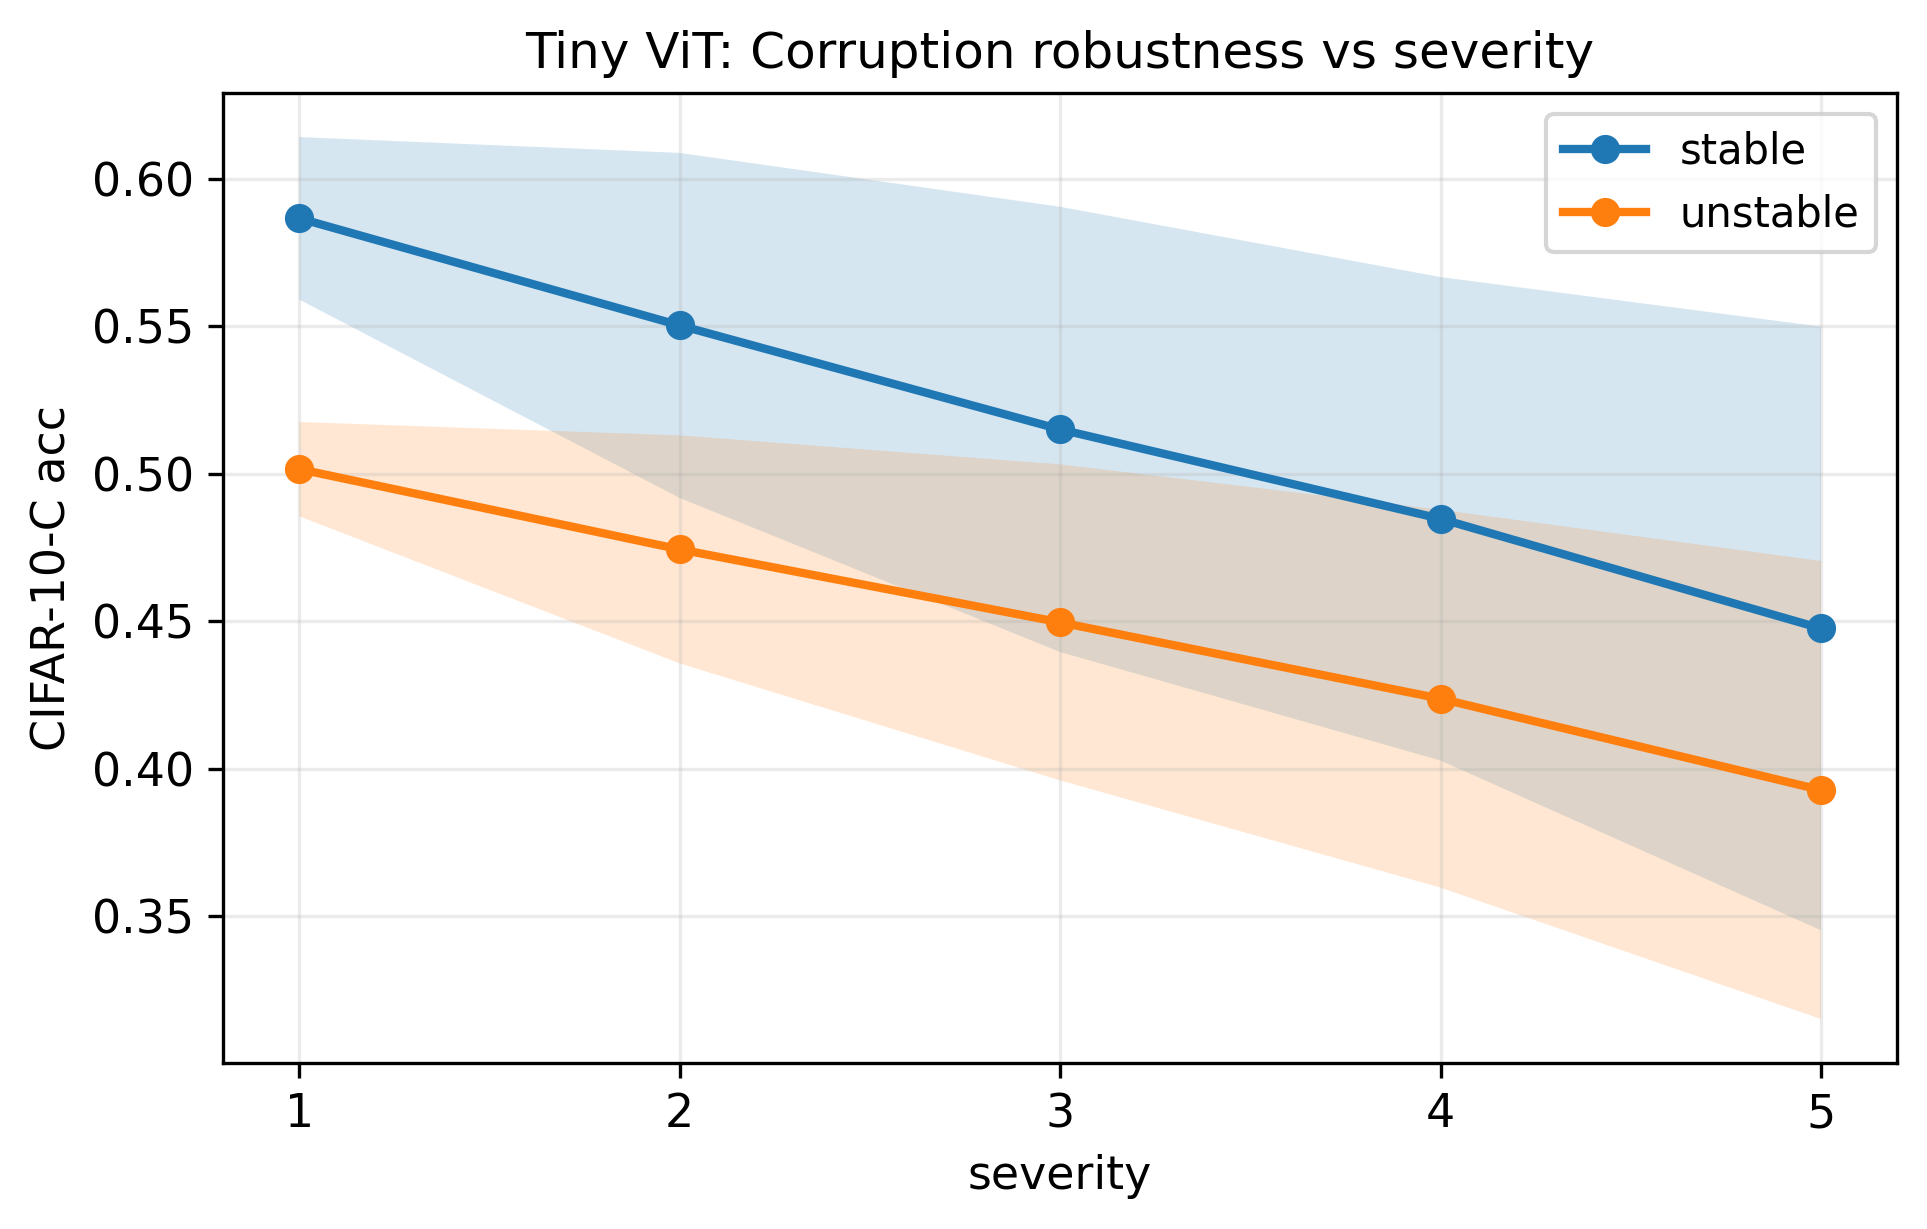

In [31]:
plt.figure(figsize=(7.2,4.2),dpi=300)
for out, label in [(stable_sev, "stable"), (unstable_sev, "unstable")]:
    sev = np.array(out["severity"])
    mu = np.array(out["mean"])
    sd = np.array(out["std"])
    plt.plot(sev, mu, marker="o", label=label)
    plt.fill_between(sev, mu-sd, mu+sd, alpha=0.18)

plt.xticks([1,2,3,4,5])
plt.xlabel("severity")
plt.ylabel("CIFAR-10-C acc")
plt.title("Tiny ViT: Corruption robustness vs severity")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 220,
    "savefig.dpi": 400,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 0.9,
    "font.family": "serif",
})

def plot_multiseverity_sensitivity_curves(
    logs,
    model_name="Tiny ViT",
    severities=(1, 3, 5),
    outfile="appendix_multiseverity_curves.pdf"
):
    S = np.array(logs["sigma_mean"], dtype=float)
    A = np.array(logs["c10c_acc_per_severity"], dtype=float)  # shape [T, 5]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # Use default matplotlib colors; no manual colors
    for sev in severities:
        y = A[:, sev - 1]

        # sort by sensitivity for smooth plotting
        idx = np.argsort(S)
        x_sorted = S[idx]
        y_sorted = y[idx]

        ax.plot(x_sorted, y_sorted, marker="o", linewidth=2.2, label=f"severity {sev}")

    ax.set_xlabel("Sensitivity surrogate")
    ax.set_ylabel("CIFAR-10-C accuracy")
    ax.set_title(f"{model_name}: sensitivity–robustness across corruption severities")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(outfile, format="pdf", bbox_inches="tight")
    plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_band(a, b, c, eta):
    """
    For R(S) = a S^2 + b S + c with a < 0,
    return S_star, R_star, (left, right) band for tolerance eta.
    """
    if a >= 0:
        raise ValueError("Quadratic must be concave (a < 0).")

    S_star = -b / (2 * a)
    R_star = a * S_star**2 + b * S_star + c
    target = (1 - eta) * R_star

    # Solve a S^2 + b S + c = target
    A = a
    B = b
    C = c - target
    disc = B**2 - 4 * A * C

    if disc < 0:
        return S_star, R_star, None

    sqrt_disc = np.sqrt(disc)
    s1 = (-B - sqrt_disc) / (2 * A)
    s2 = (-B + sqrt_disc) / (2 * A)
    left, right = min(s1, s2), max(s1, s2)

    return S_star, R_star, (left, right)


def plot_multieta_band_clean(
    S_points,
    R_points,
    a, b, c,
    model_name="Tiny ViT",
    etas=(0.01, 0.02, 0.05),
    outfile="multieta_band_clean.pdf"
):
    S_points = np.asarray(S_points, dtype=float)
    R_points = np.asarray(R_points, dtype=float)

    x_grid = np.linspace(S_points.min(), S_points.max(), 500)
    y_grid = a * x_grid**2 + b * x_grid + c

    plt.figure(figsize=(7.2, 4.8))

    # scatter + fit
    plt.scatter(S_points, R_points, s=45, alpha=0.85, label="Checkpoints")
    plt.plot(x_grid, y_grid, linewidth=2.6, label="Quadratic fit")

    # peak
    S_star = -b / (2 * a)
    R_star = a * S_star**2 + b * S_star + c
    plt.scatter([S_star], [R_star], s=80, zorder=5)
    plt.axvline(S_star, linestyle="--", linewidth=1.2)

    # sort eta so smallest band drawn last (on top)
    etas_sorted = sorted(etas, reverse=True)

    linestyles = ["-", "--", ":"]
    linewidths = [1.8, 1.5, 1.2]
    labels = ["1% Band", "2% Band", "5% Band"]

    for i, eta in enumerate(etas_sorted):
        _, _, band = quadratic_band(a, b, c, eta)
        if band is None:
            continue

        left, right = band

        # very light fill (same tone)
        plt.axvspan(left, right, alpha=0.08,color='orange')

        # distinct boundaries
        plt.axvline(left, linestyle=linestyles[i], linewidth=linewidths[i],label=labels[i],color='blue')
        plt.axvline(right, linestyle=linestyles[i], linewidth=linewidths[i],color='blue')

        # label near top
        #plt.text(
        #    (left + right) / 2,
        #    R_star - 0.01 - i * 0.01,
        #    rf"$\eta={int(eta*100)}\%$",
        #    ha="center",
        #    fontsize=11
        #)

    plt.xlabel("Sensitivity")
    plt.ylabel(r"Robustness $\mathcal{R}_5$")
    plt.title(f"{model_name}: optimal sensitivity band across $\\eta$")
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(outfile, format="pdf", bbox_inches="tight")
    plt.show()

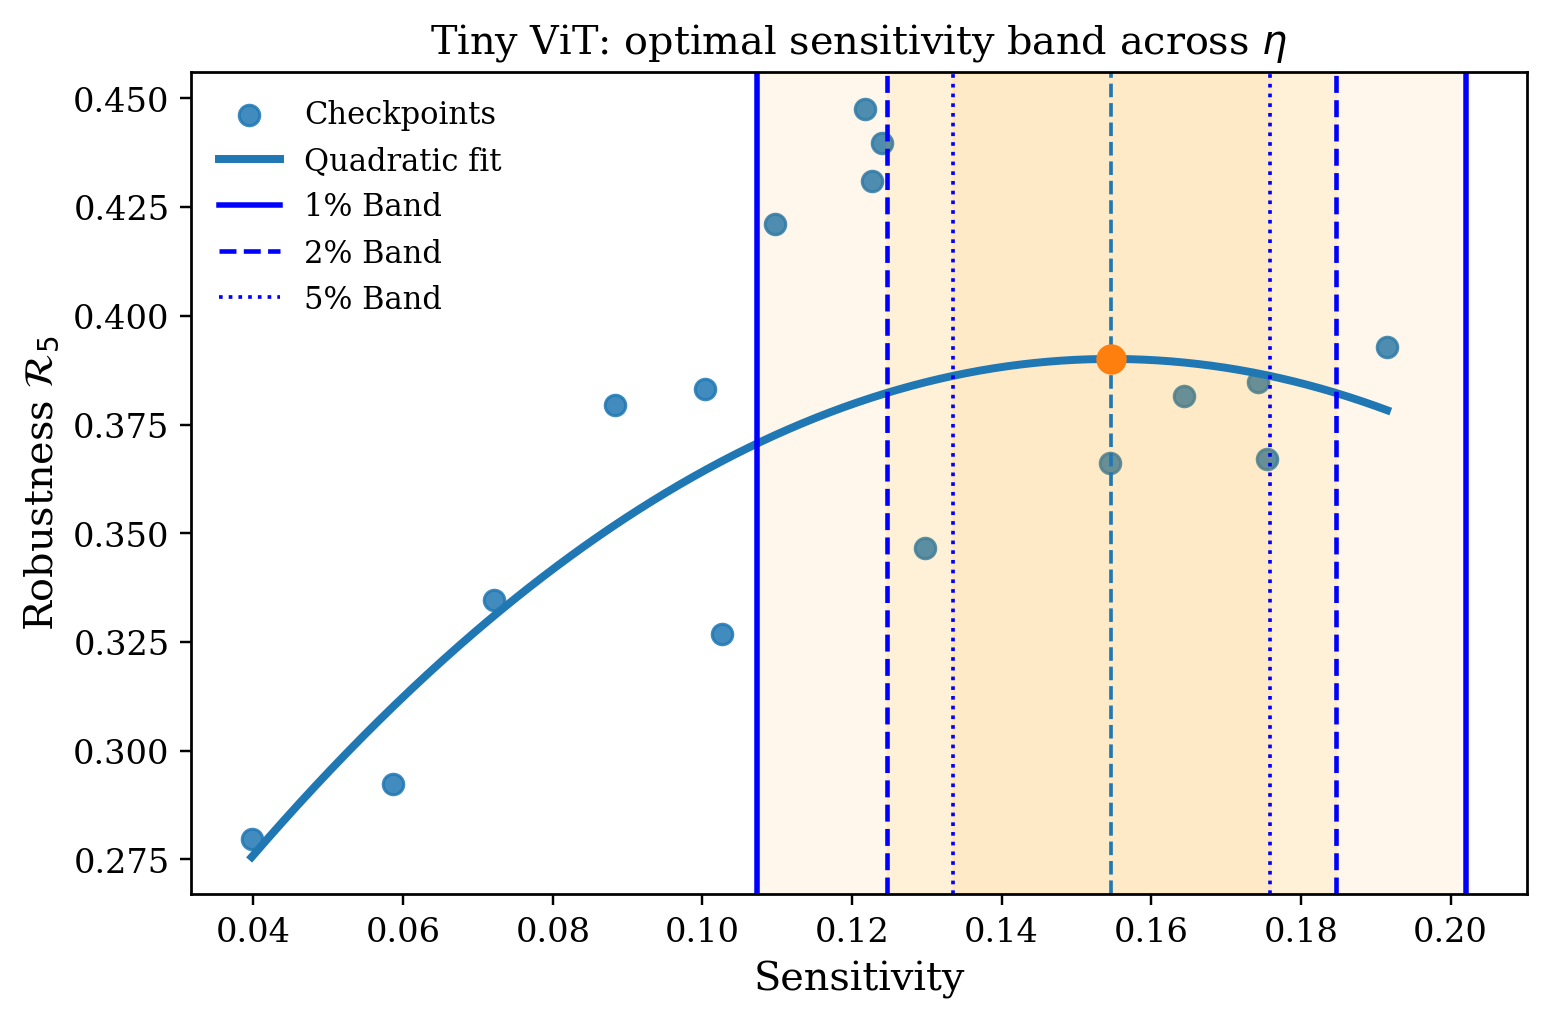

In [35]:
S_vit = np.array(vit_stable_logs["sigma_mean"] + vit_unstable_logs["sigma_mean"])
R_vit = np.array(vit_stable_logs["c10c_acc_mean"] + vit_unstable_logs["c10c_acc_mean"])

a_vit = -8.67560412977238
b_vit = 2.683503637299694
c_vit = 0.18257004953243244

plot_multieta_band_clean(
    S_vit, R_vit,
    a_vit, b_vit, c_vit,
    model_name="Tiny ViT",
    etas=(0.01, 0.02, 0.05),
    outfile="appendix_vit_multieta_band.pdf"
)